#**스마트폰 센서 데이터 기반 모션 분류**
# 단계1 : 탐색적 데이터 분석

## 0.미션

### (1) 미션①
수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **기본 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature와 중요하지 않은 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.
* 3) **각 feature 그룹별 중요도**도 파악해보며 EDA를 수행  
    * Feature 이름에는 계층구조를 담고 있습니다. 그렇다 보니 feature들을 적절하게 그룹으로 묶을 수 있습니다.
    * 참고로, feature 그룹의 중요도는 개별 feature 중요도의 합으로 계산할 수 있습니다.


### (2) 미션②  
다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* 1) Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.
* 2) Target을 **개별 행동 여부**로 구분
    * 6가지의 행동을 분류하는 분석도 중요하지만, 개별 행동에만 특별히 영향을 받는 feature들도 있습니다.
    * 예를 들어, 계단을 오르는 행동(Walking_upstairs)과 관련이 큰 feature가 있을 것입니다. [계단을 오르는 행동]인지 아닌지로 구분하는 targe을 추가하여 EDA를 수행해 봅시다.


## 1.환경설정

### (1) 라이브러리 불러오기

* 세부 요구사항
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
    - 필요하다고 판단되는 라이브러리를 추가하세요.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import *

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* 변수 중요도 함수 생성
    * 변수 중요도를 시각화할 수 있는 함수를 제공합니다.
    * 입력 :
        * importance : 트리모델의 변수 중요도(예: model.feature_importances_)
        * names : 변수 이름 목록(예 : x_train.columns
        * result_only  : 변수 중요도 순으로 데이터프레임만 return할지, 그래프도 포함할지 결정. False이면 결과 데이터프레임 + 그래프
        * topn : 중요도 상위 n개만 표시. all 이면 전체.
    * 출력 :
        * 중요도 그래프 : 중요도 내림차순으로 정렬
        * 중요도 데이터프레임 : 중요도 내림차순으로 정렬

In [ ]:
# 변수의 특성 중요도 계산하기
def plot_feature_importance(importance, names, result_only = False, topn = 'all'):
    feature_importance = np.array(importance)
    feature_name = np.array(names)

    data={'feature_name':feature_name,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    #변수의 특성 중요도 순으로 정렬하기
    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    #변수의 특성 중요도 그래프로 그리기
    if result_only == False :
        plt.figure(figsize=(10,20))
        sns.barplot(x='feature_importance', y='feature_name', data = fi_df)

        plt.xlabel('importance')
        plt.ylabel('feature name')
        plt.grid()

    return fi_df

### (2) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용 데이터셋
    * feature.csv : feature 이름을 계층구조로 정리한 데이터  
 <br/>
    

* 세부 요구사항
    - 전체 데이터 'data01_train.csv' 를 불러와 'data' 변수에 저장합니다.
    - 센서 그룹 데이터 'feature.csv' 를 불러와 'features' 변수에 저장합니다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 전체 데이터 'data01_train.csv' 를 불러와 'data' 변수에 저장합니다.
data = pd.read_csv('/content/drive/MyDrive/AI+X/스마트센서/data01_train.csv')

# 센서 그룹 데이터 'feature.csv' 를 불러와 'features' 변수에 저장합니다.
features = pd.read_csv('/content/drive/MyDrive/AI+X/스마트센서/features.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.데이터 분석 : 기본정보 살펴보기

### (1) 기본정보 확인하기 (data 로 진행)


* **세부 요구사항**
    - 불러온 데이터의 형태, 기초통계량, 정보 등을 확인합니다.
    - 데이터의 단변량 그래프를 그려서 데이터의 단변량 분석을 해 봅니다.

In [ ]:
#전체 데이터의 행,열 개수 확인
print(data.shape)

(5881, 563)


In [ ]:
#전체 데이터의 상위 5개 행 확인
display(data.head())
display(data)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying,is_walking,is_walking_up,is_walking_down
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.165163,21,STANDING,0,1,0,0,0,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.147944,15,LAYING,0,0,0,1,0,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.032755,11,STANDING,0,1,0,0,0,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.111388,17,WALKING,1,0,0,0,1,0,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0,0,0,1


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying,is_walking,is_walking_up,is_walking_down
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.165163,21,STANDING,0,1,0,0,0,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.147944,15,LAYING,0,0,0,1,0,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.032755,11,STANDING,0,1,0,0,0,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.111388,17,WALKING,1,0,0,0,1,0,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5876,0.277194,-0.012389,-0.131974,-0.994046,-0.940578,-0.917337,-0.994261,-0.932830,-0.908088,-0.936219,...,0.080146,21,SITTING,0,0,1,0,0,0,0
5877,0.191568,0.013328,-0.105174,-0.126969,-0.121729,-0.327480,-0.192523,-0.109923,-0.295286,0.078644,...,-0.044188,15,WALKING_UPSTAIRS,1,0,0,0,0,1,0
5878,0.267981,-0.018348,-0.107440,-0.991303,-0.989881,-0.990313,-0.992386,-0.988852,-0.991237,-0.936099,...,-0.571840,19,LAYING,0,0,0,1,0,0,0
5879,0.212787,-0.048130,-0.121001,-0.041373,0.052449,-0.585361,-0.100714,0.023353,-0.554707,0.219814,...,0.024920,6,WALKING_UPSTAIRS,1,0,0,0,0,1,0


In [ ]:
#전체 데이터의 수치형 변수 분포 확인
display(data.describe())

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594,17.381568
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479,8.938316
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143,1.000000
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555,8.000000
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951,19.000000
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000,30.000000


In [ ]:
#전체 데이터의 모든 변수 확인
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 25.3+ MB


None

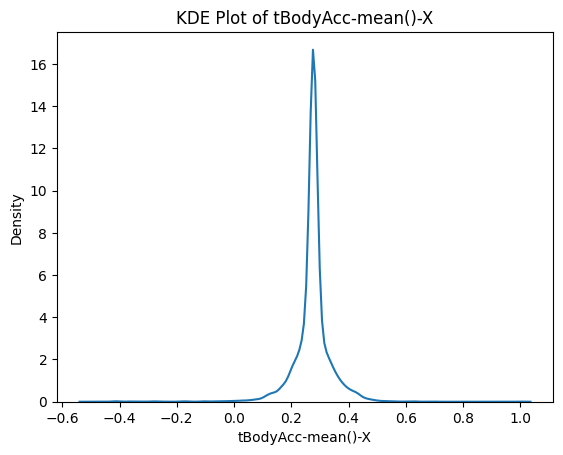

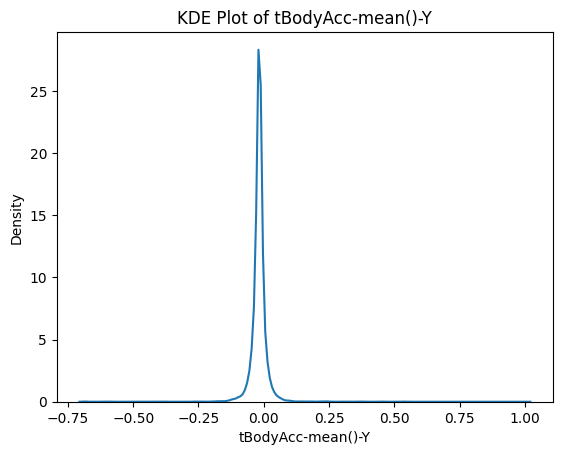

In [ ]:
# kde로 tBodyAcc-mean()-X 분포 확인하기 (단변량 분석) - 예제 일뿐 다양한 방법과 다양한 변수로 단변량 그래프를 그려보세요.
sns.kdeplot(data['tBodyAcc-mean()-X'])
plt.title('KDE Plot of tBodyAcc-mean()-X')
plt.show()

sns.kdeplot(data['tBodyAcc-mean()-Y'])
plt.title('KDE Plot of tBodyAcc-mean()-Y')
plt.show()


In [ ]:
# 전체 데이터의 이변량 분석 (corr)
display(data.corr(numeric_only=True))

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
tBodyAcc-mean()-X,1.000000,0.203297,-0.266383,0.012067,-0.018489,-0.040405,0.018367,-0.019752,-0.043303,0.048725,...,-0.012101,-0.011490,-0.567455,0.019251,0.034065,0.030968,-0.027010,0.028177,0.019025,0.027597
tBodyAcc-mean()-Y,0.203297,1.000000,-0.145709,-0.049467,-0.052489,-0.058499,-0.048703,-0.053018,-0.058559,-0.038544,...,-0.003101,-0.003467,0.076995,-0.013001,0.019670,0.074955,0.000039,0.002376,-0.022329,0.006299
tBodyAcc-mean()-Z,-0.266383,-0.145709,1.000000,-0.024839,-0.017613,-0.016924,-0.023323,-0.015794,-0.012575,-0.040397,...,0.018155,0.018234,0.056806,-0.036749,-0.054069,-0.035593,0.007045,-0.017900,-0.019169,-0.000459
tBodyAcc-std()-X,0.012067,-0.049467,-0.024839,1.000000,0.927809,0.851841,0.998656,0.921154,0.846308,0.981190,...,0.151555,0.116425,-0.043069,-0.032145,0.016542,-0.024749,-0.373500,0.470834,0.392843,-0.055562
tBodyAcc-std()-Y,-0.018489,-0.052489,-0.017613,0.927809,1.000000,0.893995,0.923386,0.997320,0.892843,0.916853,...,0.209119,0.177232,-0.027671,-0.022181,-0.012927,-0.015237,-0.380258,0.521249,0.429141,-0.107235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"angle(tBodyGyroJerkMean,gravityMean)",0.030968,0.074955,-0.035593,-0.024749,-0.015237,-0.004077,-0.025205,-0.013152,-0.004784,-0.028239,...,-0.018015,-0.015179,-0.027075,0.029856,-0.113677,1.000000,0.012598,0.005132,0.001242,0.010505
"angle(X,gravityMean)",-0.027010,0.000039,0.007045,-0.373500,-0.380258,-0.346237,-0.370024,-0.376665,-0.348279,-0.385300,...,-0.088810,-0.080113,0.012382,0.020700,-0.001992,0.012598,1.000000,-0.783107,-0.639201,0.012622
"angle(Y,gravityMean)",0.028177,0.002376,-0.017900,0.470834,0.521249,0.473572,0.466287,0.522401,0.474880,0.478832,...,0.092383,0.080726,-0.000955,-0.013508,-0.013863,0.005132,-0.783107,1.000000,0.590883,0.002219
"angle(Z,gravityMean)",0.019025,-0.022329,-0.019169,0.392843,0.429141,0.480593,0.389196,0.427486,0.477848,0.401217,...,0.056005,0.049690,-0.004422,-0.014844,-0.021702,0.001242,-0.639201,0.590883,1.000000,-0.085036


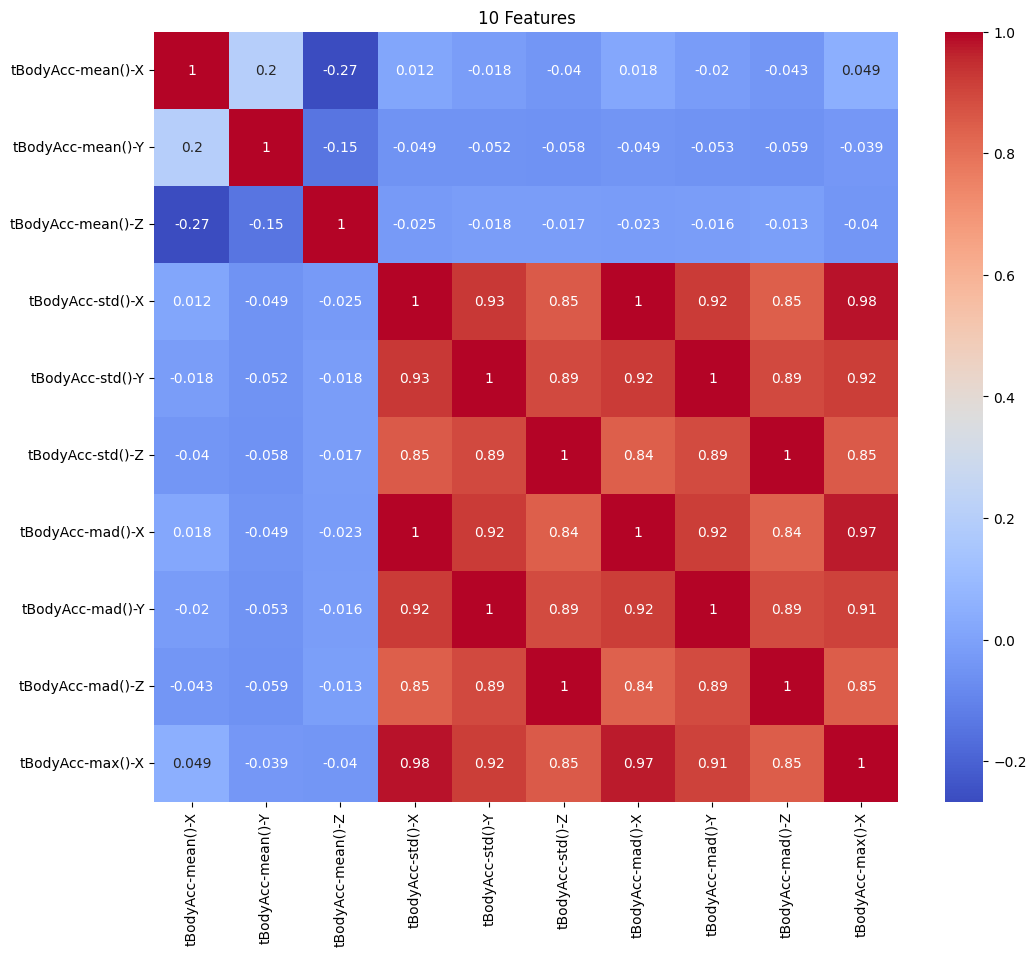

In [ ]:
# 이변량 시각화 하기  (변수를 줄여서도 해보기))
plt.figure(figsize=(12, 10))
sns.heatmap(data.iloc[:, :10].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('10 Features')
plt.show()

이것이 의미하는 바가 무엇일까?
std / mad / max는 서로 대체 가능한 특징임을 알 수 있음, 이 여러가지 특징을 줄일 수 있다.

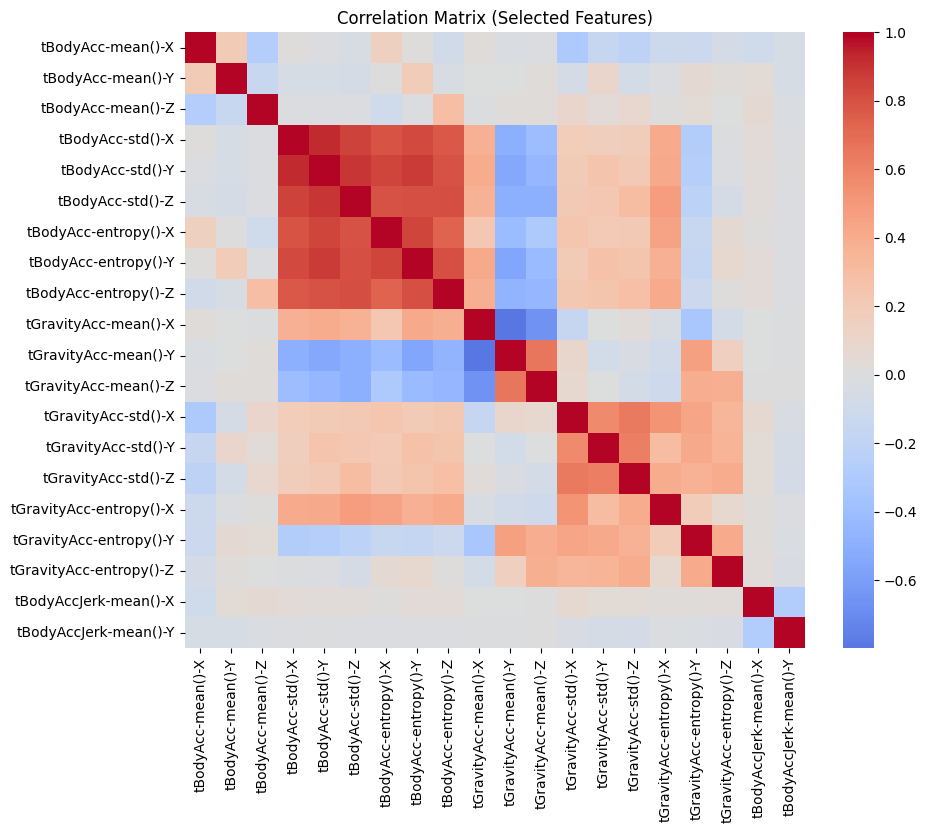

In [ ]:
subset_cols = features.query("agg in ['mean()', 'std()', 'entropy()']").feature_name.tolist()[:20]
corr = data[subset_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Selected Features)')
plt.show()


### (2) 목표 변수 확인하기

* **세부 요구사항**
    - target인 'Activity'에 대해 단변량 분석을 수행합니다.
    - 범주의 종류, 범주별 빈도수 및 비율 등

In [ ]:
# target인 'Activity'의 고유값 확인
print(data['Activity'].unique())

['STANDING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS'
 'SITTING']


In [ ]:
# target인 'Activity'의 범주별 빈도수 확인
activity_counts = data['Activity'].value_counts()
print(activity_counts)

Activity
LAYING                1115
STANDING              1087
SITTING               1032
WALKING                998
WALKING_UPSTAIRS       858
WALKING_DOWNSTAIRS     791
Name: count, dtype: int64


Activity
LAYING                0.189594
STANDING              0.184833
SITTING               0.175480
WALKING               0.169699
WALKING_UPSTAIRS      0.145894
WALKING_DOWNSTAIRS    0.134501
Name: proportion, dtype: float64


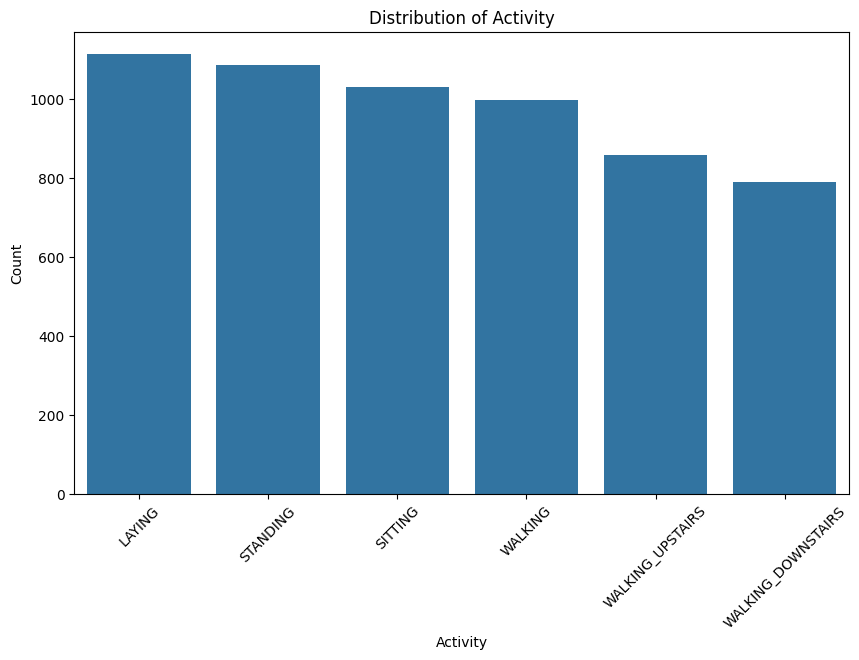

In [ ]:
# target인 'Activity'의 범주별 비율 및 시각화
activity_ratios = data['Activity'].value_counts(normalize=True)
print(activity_ratios)

plt.figure(figsize=(10, 6))
sns.barplot(x=activity_counts.index, y=activity_counts.values)
plt.title('Distribution of Activity')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### (3) 센서 그룹 데이터: features

* **세부 요구사항**
    - feature 이름에 대한 계층 구조별로 변수의 수를 카운트 해 봅시다.
        - sensor 별 변수의 개수
        - agg(regation) 별 변수의 개수
        - axis 별 변수의 개수

In [ ]:
# 센서 그룹 데이터의 'sensor'변수의 값 확인
display(features['sensor'].value_counts())

,count
sensor,
fBodyGyro,79
fBodyAccJerk,79
fBodyAcc,79
tBodyAcc,40
tGravityAcc,40
tBodyAccJerk,40
tBodyGyroJerk,40
tBodyGyro,40
tGravityAccMag,13


In [ ]:
# 센서 그룹 데이터의 'agg'변수의 값 확인
display(features['agg'].value_counts())

,count
agg,
bandsEnergy(),126
arCoeff(),60
std(),33
mad(),33
max(),33
energy(),33
min(),33
entropy(),33
iqr(),33


In [ ]:
# 센서 그룹 데이터의 'axis'변수의 값 확인
display(features['axis'].value_counts())

,count
axis,
X,76
Y,76
Z,76
gravityMean,6
"X,2",5
...,...
"17,32.2",2
"49,64.2",2
"1,24.2",2


### 동적 vs 정적 그룹 비교
어떤 features가 동적과 정적을 구분하는 데 중요한지 알아내기
+ 동적(1): WALKING / WALKING_UPSTAIRS / WALKING_DOWNSTAIRS
+ 정적(0): STANDING / SITTING / LAYING

In [ ]:
# 동적 행동 리스트
dynamic_actions = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

# 새로운 컬럼 is_dynamic 생성 하기
data['is_dynamic'] = data['Activity'].apply(lambda x: 1 if x in dynamic_actions else 0)

display(data[['Activity','is_dynamic']])

,Activity,is_dynamic
0,STANDING,0
1,LAYING,0
2,STANDING,0
3,WALKING,1
4,WALKING_DOWNSTAIRS,1
...,...,...
5876,SITTING,0
5877,WALKING_UPSTAIRS,1
5878,LAYING,0
5879,WALKING_UPSTAIRS,1


In [ ]:
# 대표 feature 10개 정도만 우선 비교
target_cols = [
    'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
    'tBodyAccMag-mean()', 'tBodyAccMag-std()',
    'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z'
]

group_stats = data.groupby('is_dynamic')[target_cols].mean().T
display(group_stats)

is_dynamic,0,1
tBodyAcc-mean()-X,0.274339,0.275388
tBodyAcc-mean()-Y,-0.015808,-0.020232
tBodyAcc-mean()-Z,-0.107126,-0.112169
tBodyAccMag-mean(),-0.948868,-0.045016
tBodyAccMag-std(),-0.939182,-0.158641
tGravityAcc-mean()-X,0.466979,0.910812
tGravityAcc-mean()-Y,0.195986,-0.217278
tGravityAcc-mean()-Z,0.238427,-0.088328


위의 결과를 한번 해석해 보자!

+ tBodyAcc-mean()-X,Y,Z
    + 정적일떄와 동적일때의 값의 변화가 매우 적은 것을 통해 동적, 정적을 구분하는데 유효하지 않다고 볼 수 있다.
+ tBodyAccMag-mean(), tBodyAccMag-std()
    + 정적일 때와 동적일 때의 값의 차이가 큰 것을 통해서 동적 행동을 판단하는 데 중요한 특징임을 알 수 있다.
+ tGravityAcc-mean()-X,Y,Z
    + 정적인 경우에는 x,y,z의 평균이 대부분 유사하다.
    + 동적인 경우에는 x,y,z의 평균에서 일부 띄는 값이 존재한다.

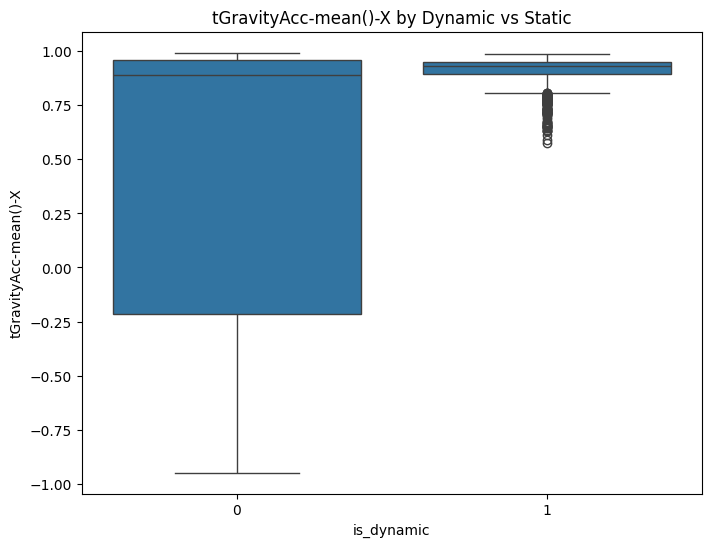

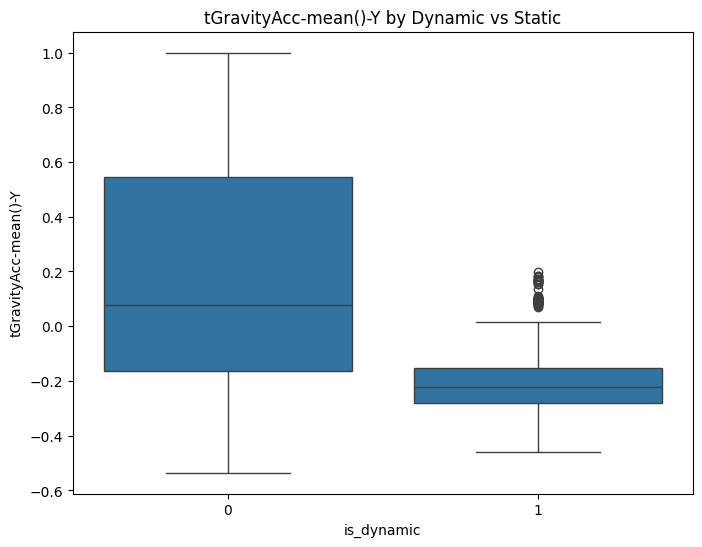

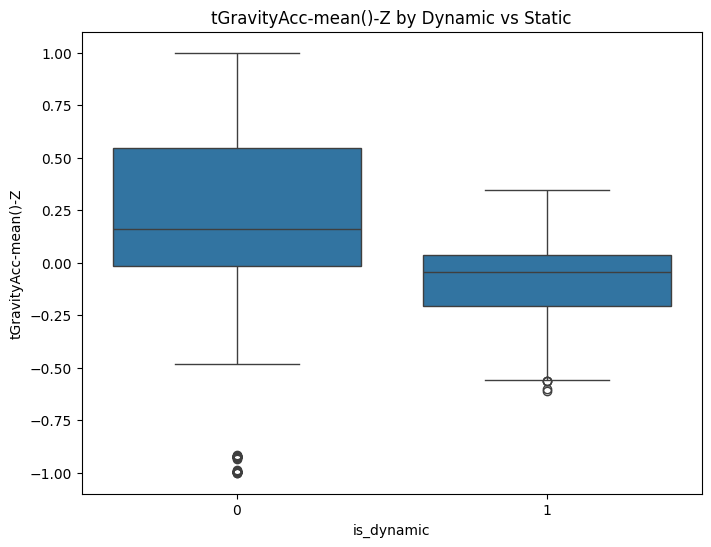

In [ ]:
# 더 해보자

# 1. Acc mean/std 비교해보기
cols1 = ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
         'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z']
# 박스플롯를 통한 해석 결과 : std를 통한 정적, 동적 구분이 더 좋다

# 2. Magnitude 계열
cols2 = ['tBodyAccMag-mean()', 'tBodyAccMag-std()',
         'tBodyAccMag-max()', 'tBodyAccMag-min()']
# 헤석 결과 : tBodyAcc 계열(mean, std, max, min)은 동적일때 더 활성화 되는 것을 볼 수 있어서, 동적과 정적을 구분하는데 좋다고 할 수 있음

# 3. Gravity 계열
cols3 = ['tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z']
# 해석 결과 : 정적 동적을 구분하는데 유용하게 사용할 수 있음, 오히려 동적일 떄 중력이 안정적

# 4. Jerk 계열
cols4 = ['tBodyAccJerk-mean()-X', 'tBodyAccJerk-std()-X',
         'tBodyAccJerk-mean()-Y', 'tBodyAccJerk-std()-Y']
# 해석 결과 : 동작 중 발생하는 급격한 변화 나타남 -> 동적에 중요한 특징

# 5. Frequency domain
cols5 = ['fBodyAcc-bandsEnergy()-1,8', 'fBodyAcc-bandsEnergy()-9,16',
         'fBodyAcc-meanFreq()-X']

for col in cols3:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=data, x='is_dynamic', y=col)
    plt.title(f'{col} by Dynamic vs Static')
    plt.show()


Magnitude(tBodyAccMag-mean/std/max/min)와 Jerk (tBodyAccJerk-std 등)은
정적/동적 구분에 가장 중요한 특징

Frequency domain 계열은 동적에서도 걷기와 같은 특정 동적 행동을 발견하는데 유용한 특징

## 6가지 행동 중 특정 행동(WALKING_UPSTAIRS 등)에 특히 반응하는 특징을 찾기

특정 activity에만 값이 튀는 특징 찾기

In [ ]:
activity_groups = data.groupby("Activity")[cols1 + cols2 + cols3 + cols4 + cols5].mean()
display(activity_groups)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAccMag-mean(),tBodyAccMag-std(),tBodyAccMag-max(),tBodyAccMag-min(),tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z,tBodyAccJerk-mean()-X,tBodyAccJerk-std()-X,tBodyAccJerk-mean()-Y,tBodyAccJerk-std()-Y,"fBodyAcc-bandsEnergy()-1,8","fBodyAcc-bandsEnergy()-9,16",fBodyAcc-meanFreq()-X
Activity,,,,,,,,,,,,,,,,,,,,
LAYING,0.271483,-0.018417,-0.107785,-0.960691,-0.937412,-0.942267,-0.934034,-0.926903,-0.932019,-0.971575,-0.368345,0.633626,0.571230,0.080726,-0.980225,0.011556,-0.970325,-0.995835,-0.999349,-0.269027
SITTING,0.272837,-0.012072,-0.106352,-0.983166,-0.937754,-0.940105,-0.955795,-0.940376,-0.946416,-0.986647,0.870634,0.125066,0.162482,0.075753,-0.985502,0.006258,-0.974570,-0.999099,-0.999716,-0.049526
STANDING,0.278693,-0.016679,-0.107184,-0.985546,-0.937629,-0.943353,-0.957508,-0.950644,-0.951294,-0.985886,0.940588,-0.185597,-0.030847,0.075113,-0.981341,0.009085,-0.966898,-0.999694,-0.999577,0.006802
WALKING,0.275589,-0.017413,-0.109834,-0.308924,-0.019184,-0.245919,-0.158130,-0.328223,-0.222221,-0.648878,0.933800,-0.198665,-0.064525,0.078603,-0.277207,0.010038,-0.102358,-0.760607,-0.815083,-0.304986
WALKING_DOWNSTAIRS,0.290086,-0.016740,-0.105793,0.137657,0.073628,-0.172184,0.133842,0.141573,0.187691,-0.650238,0.924807,-0.164610,-0.049657,0.094806,-0.011011,-0.000564,-0.067011,-0.271675,-0.590187,-0.399928
WALKING_UPSTAIRS,0.261603,-0.026729,-0.120764,-0.222087,-0.005984,-0.145224,-0.078337,-0.238159,-0.166155,-0.690156,0.871170,-0.287482,-0.151665,0.080381,-0.359682,0.010831,-0.331628,-0.649581,-0.824512,-0.444260


### LAYING

Gravity X,Y,Z가 확연히 다름

tGravityAcc-mean()-X  -0.36,
tGravityAcc-mean()-Y  0.63,
tGravityAcc-mean()-Z  0.57

Gravity-X가 강하게 나타남

중력 특정 방향 특징 -> 눕는 상태임을 알 수 있음

### SITTING

Gravity는 LAYING보다 약하지만 중력의 영향을 많이 받는 것을 알 수 있음

tGravityAcc-mean()-X  0.87,
tGravityAcc-mean()-Z  0.16,
tGravityAcc-mean()-Y  0.12

Gravity-Y가 높음

중력 벡터로 앉은 상태임 알 수 있음

### STANDING

Sitting과 비슷하지만 Gravity X가 더 강함

tGravityAcc-mean()-X  0.94,
tGravityAcc-mean()-Y  -0.03,
tGravityAcc-mean()-Z  0.03

가장 서있는 상태에서 Gravity X가 가장 큼

### WALKING

정적 상태 보다 동적 상태로 Acc/Jerk의 std가 증가함을 알 수 있음

tBodyAccMag-std  -0.32,
tBodyAccMag-mean()  -0.15,
tBodyAccJerk-std()-X  -0.27

Gravity는 X,Y 값 변경을 통해 움직임을 알 수 있음
Acc/Jerk 변화가 커서 쉽게 동적 판별 가능

### WALKING_UPSTAIRS

동적이지만 위쪽 동작이 포함 → Z축 강함

tGravityAcc-mean()-X  0.87,
tBodyAccJerk-std()-X  -0.35 (가장 크다),
tBodyAccMag-max  -0.166

Jerk-std(X,Y)가 매우 높음

fBodyAcc-bandsEnergy 계열이 크게 떨어진 것을 볼 수 있음
"계단 오르는데" jerk std가 높은 것을 볼 수 있음

### WALKING_DOWNSTAIRS

tBodyAccJerk-std()-Y  -0.067,
tBodyAccMag-std  0.14,
tBodyAccMag-max  0.18

AccMag-min이 매우 낮음

Gravity Y가 음수 방향으로 치우친 것을 볼 수 있음

## 3.데이터 분석 : 미션1

수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **기본 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature와 중요하지 않은 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.
* 3) **각 feature 그룹별 중요도**도 파악해보며 EDA를 수행  
    * Feature 이름에는 계층구조를 담고 있습니다. 그렇다 보니 feature들을 적절하게 그룹으로 묶을 수 있습니다.
    * 참고로, feature 그룹의 중요도는 개별 feature 중요도의 합으로 계산할 수 있습니다.

### (1) 기본모델링 + 변수중요도 추출

* **세부 요구사항**
    - 모델링을 위한 기본 전처리를 수행합니다.
        - 주어진 데이터에서는 x, y로 나누고 train과 validation 분할 수행
    - 트리기반 알고리즘을 이용하여 모델링을 합니다.
        - 랜덤포레스트 권장 : 랜덤포레스트는 튜닝 없이 하이퍼파리미터의 기본값로도 적절한 성능의 모델을 생성할 수 있습니다.
    - 변수 중요도 추출
        - 사용자정의함수로 생성한 plot_feature_importance 을 이용
        - 변수중요도 파악및 결과 저장

#### 1) 데이터 전처리

In [ ]:
# 데이터 분할을 위한 전처리
target = 'Activity'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .3)

#### 2) 모델링

In [ ]:
#생성
model = RandomForestClassifier()

#학습
model.fit(x_train, y_train)
pred = model.predict(x_val)

#평가
print('accuracy :',accuracy_score(y_val, pred))
print('='*60)
print(confusion_matrix(y_val, pred))
print('='*60)
print(classification_report(y_val, pred))

accuracy : 0.9722379603399434
[[333   0   0   0   0   0]
 [  0 295  20   0   0   0]
 [  0  15 321   0   0   0]
 [  0   0   0 276   7   2]
 [  0   0   0   2 239   1]
 [  0   0   0   1   1 252]]
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       333
           SITTING       0.95      0.94      0.94       315
          STANDING       0.94      0.96      0.95       336
           WALKING       0.99      0.97      0.98       285
WALKING_DOWNSTAIRS       0.97      0.99      0.98       242
  WALKING_UPSTAIRS       0.99      0.99      0.99       254

          accuracy                           0.97      1765
         macro avg       0.97      0.97      0.97      1765
      weighted avg       0.97      0.97      0.97      1765



#### 3) 변수 중요도 추출

In [ ]:
# 변수 중요도 추출
r0 = plot_feature_importance(model.feature_importances_, list(x_train.columns), result_only=True)

#### 4) feature importance 데이터 가져오기
위 모델링을 통해 생성한 feature별 중요도 데이터를 제공해 드립니다. random forest 모델링이 너무 어렵다면, 해당 데이터를 활용해도 무방합니다.

In [ ]:
#fi_analysis 데이터 불러오기
#data_path = "./fi_analysis.csv"
#fi_analysis = pd.read_csv(data_path)
#r0 = fi_analysis.filter(items=['feature_name','fi_all'])
#r0.rename(columns={'fi_all':'feature_importance'}, inplace=True)
#r0.sort_values(by=['feature_importance'], axis=0, ascending=False)

### (2) 중요도 기반 feature 분석

* **세부 요구사항**
    - 상위 n, 하위 m 개의 변수를 선정
    - 선정된 변수(feature)와 target 간의 관계를 kdeplot으로 그리기

상위 3개 중요 변수: ['tGravityAcc-mean()-Y', 'angle(X,gravityMean)', 'tGravityAcc-energy()-X']


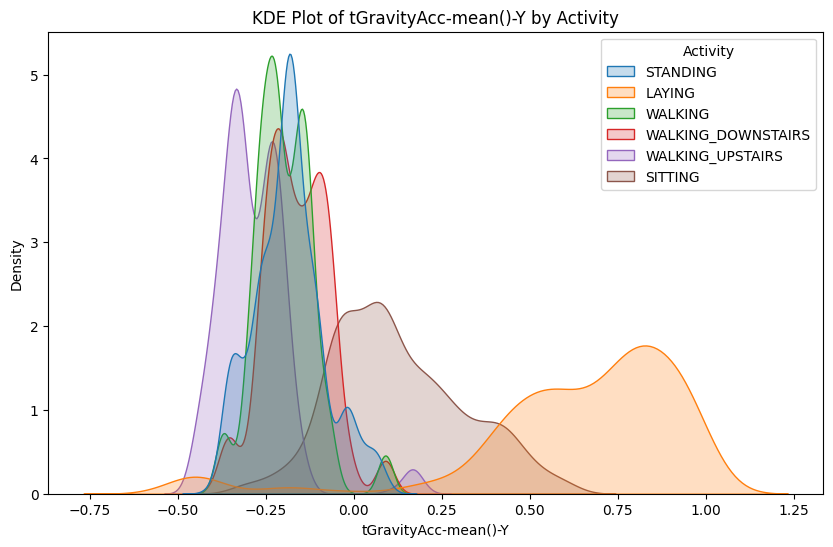

In [ ]:
# 상위 3개 중요 변수 선정
top_n = 3
top_features = r0['feature_name'].head(top_n).tolist()

print(f"상위 {top_n}개 중요 변수: {top_features}")

# 첫 번째 상위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=top_features[0], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {top_features[0]} by Activity')
plt.show()

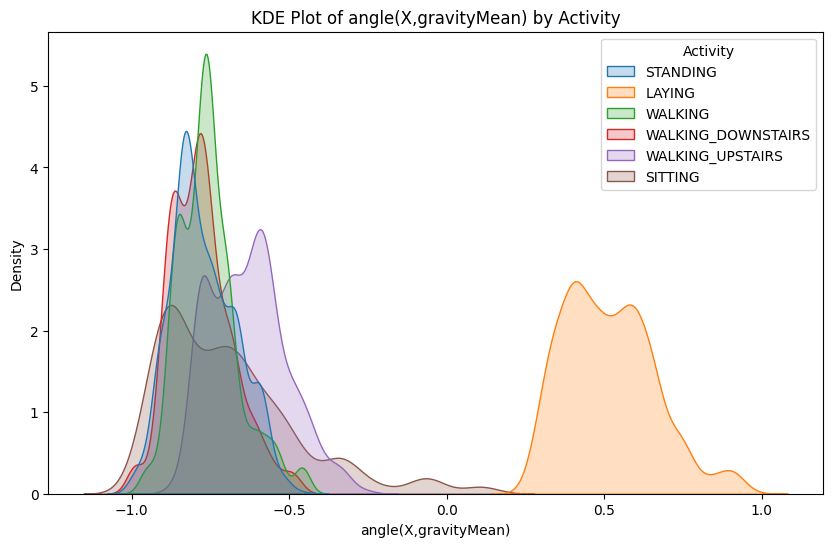

In [ ]:
# 두 번째 상위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=top_features[1], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {top_features[1]} by Activity')
plt.show()

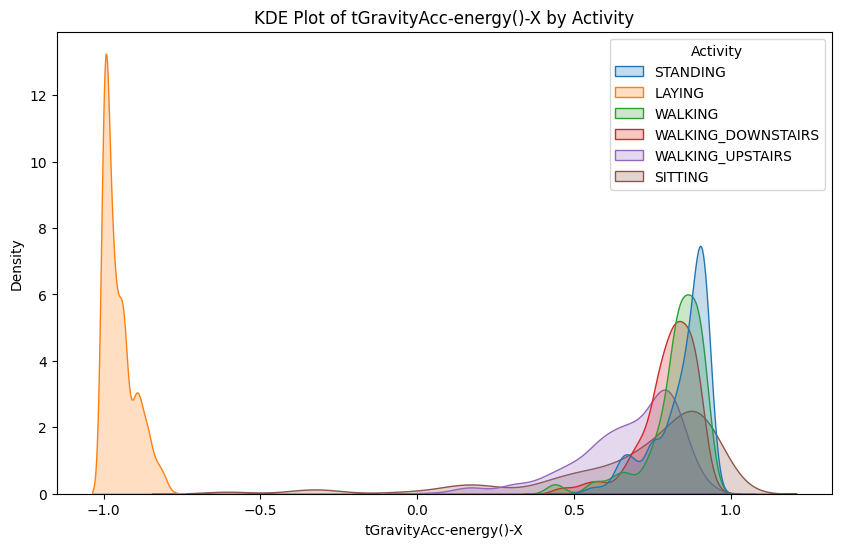

In [ ]:
# 세 번째 상위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=top_features[2], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {top_features[2]} by Activity')
plt.show()

하위 3개 중요 변수: ['tBodyAccJerkMag-max()', 'fBodyAcc-bandsEnergy()-49,64', 'fBodyGyro-min()-Y']


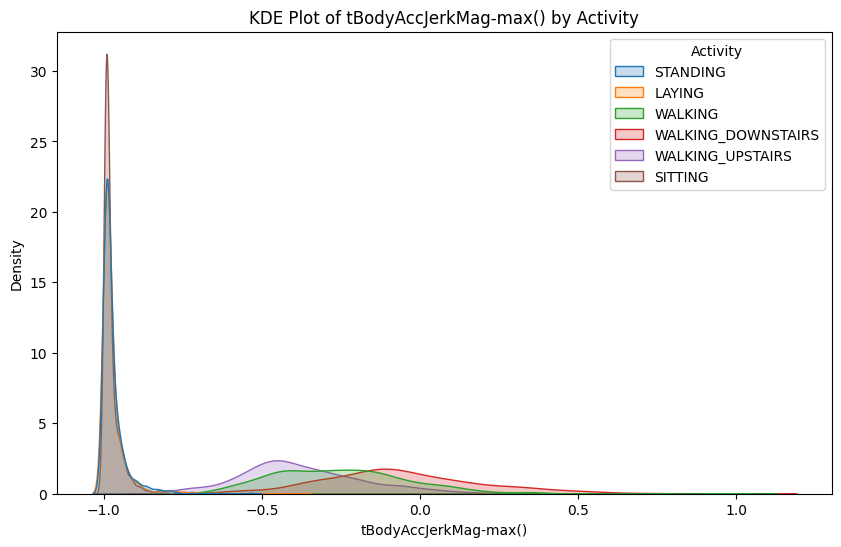

In [ ]:
# 하위 3개 중요 변수 선정
bottom_m = 3
bottom_features = r0['feature_name'].tail(bottom_m).tolist()

print(f"하위 {bottom_m}개 중요 변수: {bottom_features}")

# 첫 번째 하위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=bottom_features[0], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {bottom_features[0]} by Activity')
plt.show()

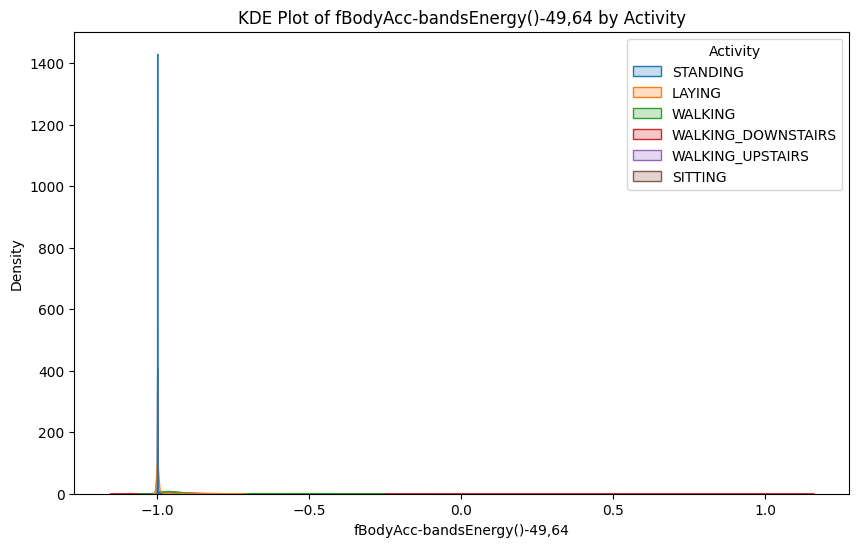

In [ ]:
# 두 번째 하위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=bottom_features[1], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {bottom_features[1]} by Activity')
plt.show()

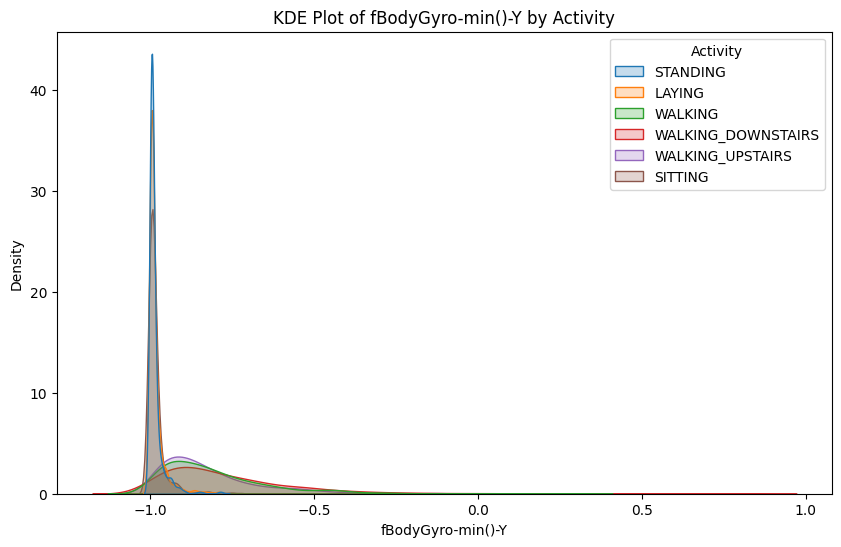

In [ ]:
# 세 번째 하위 변수 KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x=bottom_features[2], hue='Activity', fill=True, common_norm=False)
plt.title(f'KDE Plot of {bottom_features[2]} by Activity')
plt.show()

### (3) feature 그룹별 분석

* **세부 요구사항**
    - 제공된 features.csv 에는 feature에 대한 계층구조를 정리해 놓았습니다.
    - features와 변수중요도 결과를 merge 하시오.
    - sensor 별 중요도 합계를 구하고 상위 변수 그룹별 비교 분석을 수행 하시오.
    - sensor + agg 별 중요도 합계를 구하고 상위 변수 그룹별 비교 분석을 수행 하시오.


#### 1) 결과 merge

In [ ]:
import re

def parse_feature_name_to_components(feature_name):
    sensor = 'UNKNOWN'
    agg = 'UNKNOWN'
    axis = 'None'

    if feature_name.startswith('angle'):
        sensor = 'angle'
        match = re.search(r'angle\((.*?)(?:,(.*?))?\)', feature_name)
        if match:
            agg_part = match.group(1)
            axis_part = match.group(2)
            agg = agg_part.strip() if agg_part else 'None'
            axis = axis_part.strip() if axis_part else 'None'
    else:
        # Split by hyphen
        parts = feature_name.split('-')
        sensor = parts[0]
        if len(parts) > 1:
            # Check if the last part is an axis (X, Y, Z)
            if parts[-1] in ['X', 'Y', 'Z']:
                axis = parts[-1]
                agg = '-'.join(parts[1:-1])  # Aggregate remaining middle parts
            else:
                agg = '-'.join(parts[1:])  # Aggregate all parts after sensor

            if not agg:  # If agg is empty, set to None
                agg = 'None'

    return sensor, agg, axis

# r0에 새로운 컬럼 생성
r0[['sensor', 'agg', 'axis']] = r0['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head):")
display(r0.head())

Feature importance dataframe with parsed components (head):


,feature_name,feature_importance,sensor,agg,axis
0,tGravityAcc-mean()-Y,0.033247,tGravityAcc,mean(),Y
1,"angle(X,gravityMean)",0.032505,angle,X,gravityMean
2,tGravityAcc-energy()-X,0.031444,tGravityAcc,energy(),X
3,tGravityAcc-min()-X,0.029127,tGravityAcc,min(),X
4,tGravityAcc-mean()-X,0.027148,tGravityAcc,mean(),X


#### 2) sensor 별 중요도


Sensor 별 중요도 합계:


,sensor,feature_importance
18,tGravityAcc,0.327062
2,fBodyAccJerk,0.104750
1,fBodyAcc,0.087315
0,angle,0.068170
7,fBodyGyro,0.060802
11,tBodyAccJerk,0.046801
3,fBodyAccMag,0.046720
10,tBodyAcc,0.046134
15,tBodyGyroJerk,0.041672
12,tBodyAccJerkMag,0.032884


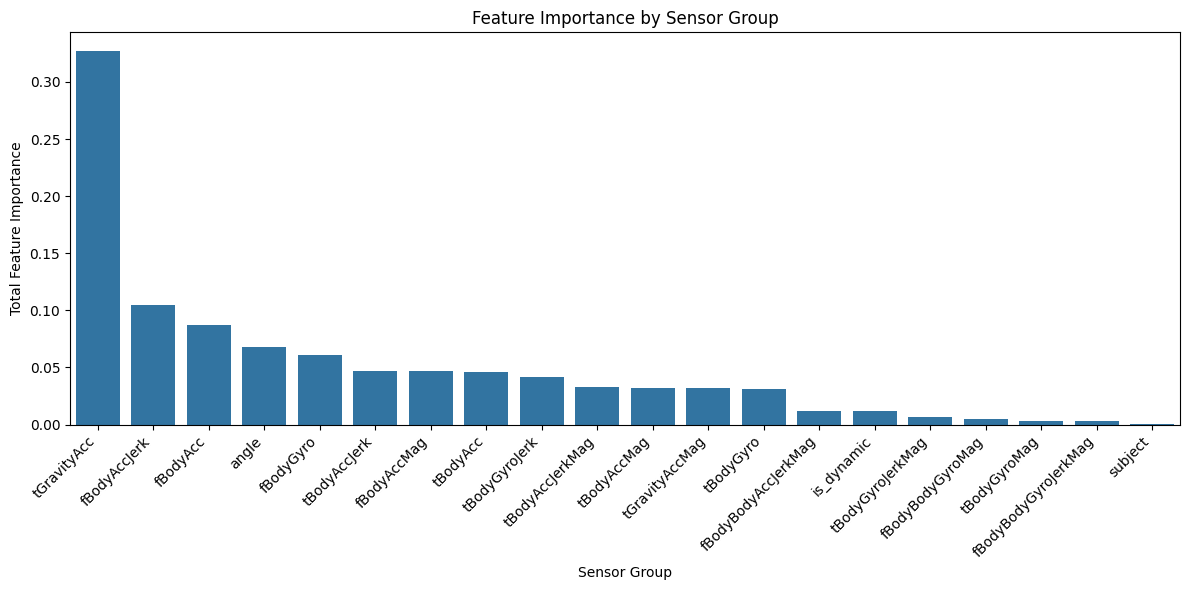

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance = r0.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance = sensor_importance.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계:")
display(sensor_importance)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance)
plt.title('Feature Importance by Sensor Group')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3) sensor + agg 별 중요도


Sensor + Aggregation 별 중요도 합계 (상위 10개):


,sensor,agg,feature_importance
394,tGravityAcc,mean(),0.068473
395,tGravityAcc,min(),0.056386
389,tGravityAcc,energy(),0.056045
393,tGravityAcc,max(),0.048835
0,angle,X,0.032505
1,angle,Y,0.024427
105,fBodyAccJerk,entropy(),0.014345
383,tGravityAcc,"arCoeff()-Z,2",0.013480
342,tBodyGyroJerk,mad(),0.012809
279,tBodyAccJerkMag,entropy(),0.012308


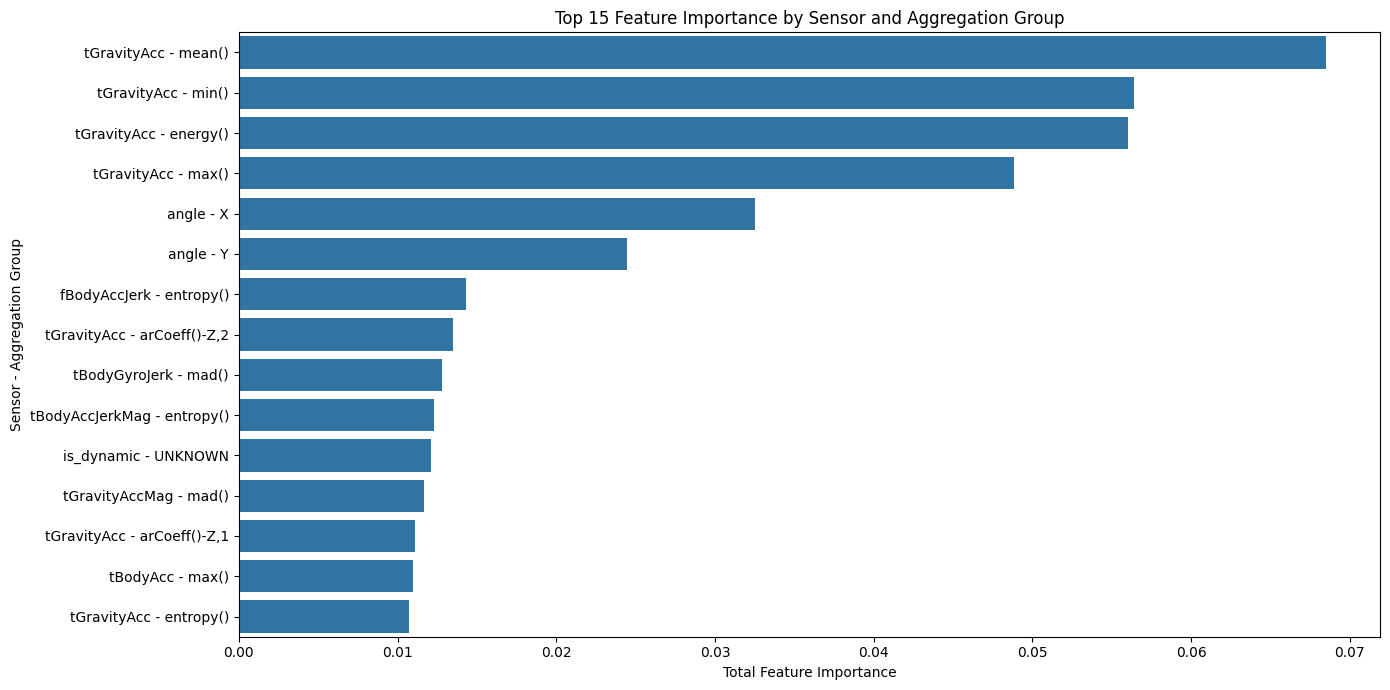

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance = r0.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance = sensor_agg_importance.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (상위 10개):")
display(sensor_agg_importance.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance['sensor_agg_group'] = sensor_agg_importance['sensor'] + ' - ' + sensor_agg_importance['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

#### 3-1) sensor 별, agg로 나눠서 분석하기


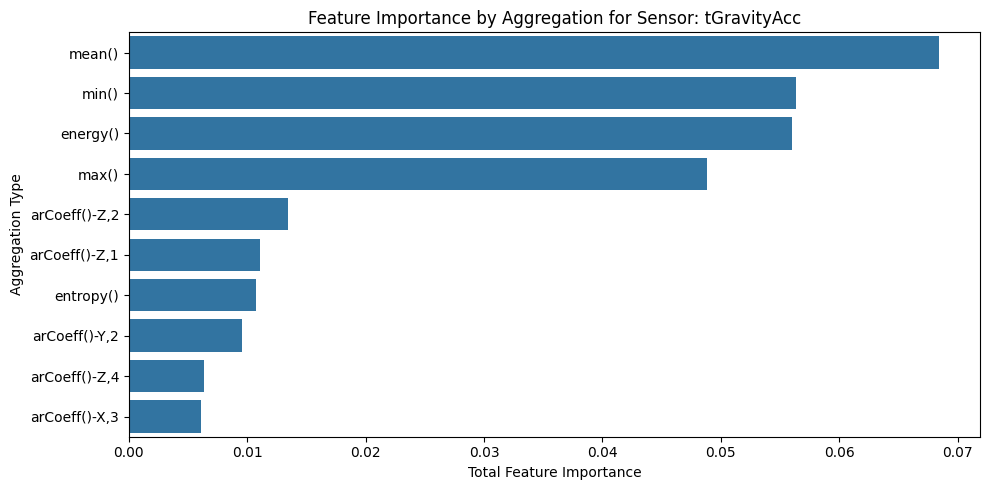

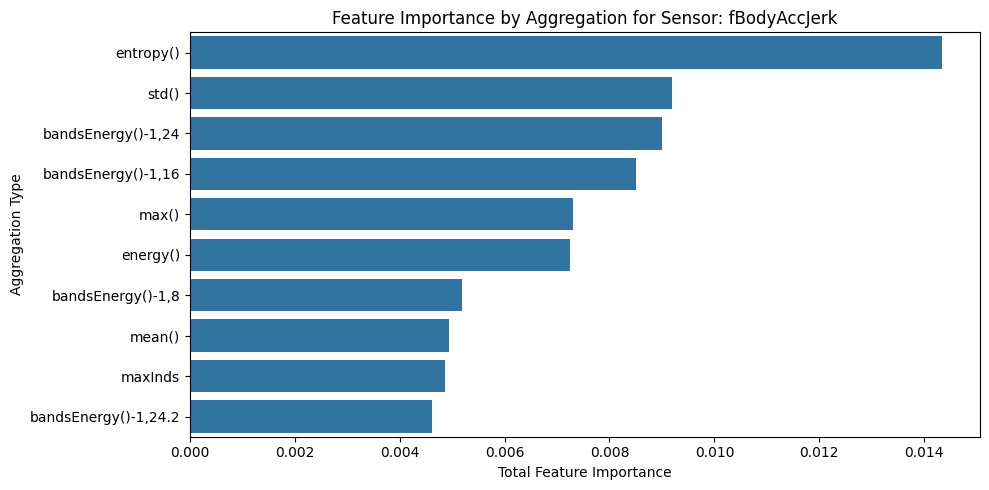

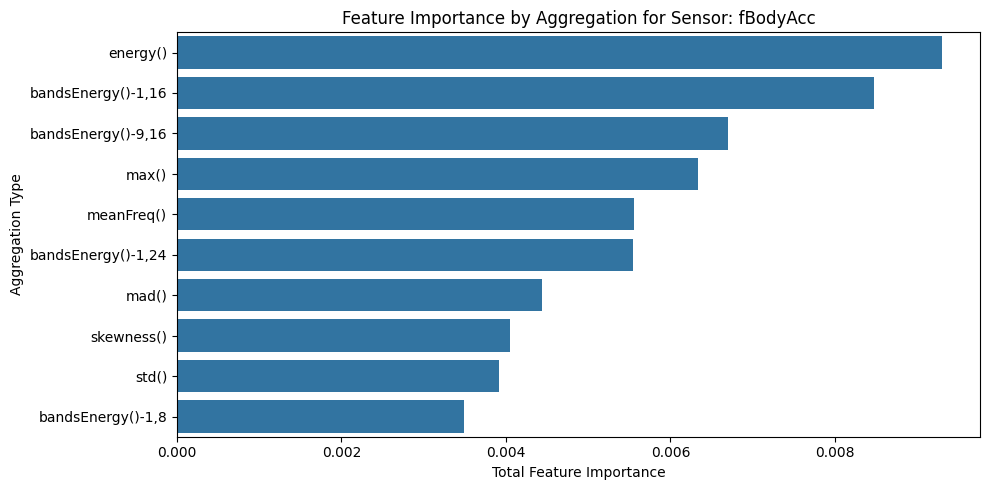

In [ ]:
# 상위 3개 센서 그룹에 대해 Aggregation 별 중요도 시각화
top_sensors_for_analysis = sensor_importance['sensor'].head(3).tolist()

for s in top_sensors_for_analysis:
    subset = sensor_agg_importance[sensor_agg_importance['sensor'] == s].sort_values(by='feature_importance', ascending=False)
    if not subset.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(x='feature_importance', y='agg', data=subset.head(10)) # 해당 센서의 상위 10개 Aggregation
        plt.title(f'Feature Importance by Aggregation for Sensor: {s}')
        plt.xlabel('Total Feature Importance')
        plt.ylabel('Aggregation Type')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No aggregation data found for sensor: {s}")

## 4.데이터 분석 : 미션2

다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* 1) Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.
* 2) Target을 **개별 행동 여부**로 구분
    * 6가지의 행동을 분류하는 분석도 중요하지만, 개별 행동에만 특별히 영향을 받는 feature들도 있습니다.
    * 예를 들어, 계단을 오르는 행동(Walking_upstairs)과 관련이 큰 feature가 있을 것입니다. [계단을 오르는 행동]인지 아닌지로 구분하는 targe을 추가하여 EDA를 수행해 봅시다.

### (1) 정적/동적 행동으로 구분하여 분석하기

* **세부 요구사항**
    - Target인 Activity를 is_dynamic 변수로 변경하시오. (컬럼을 하나 더 만들기)
        * 값 0 : STANDING, SITTING, LAYING
        * 값 1 : WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS
    - is_dynamic을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_dynamic을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_dynamic 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_dynamic 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


#### 1) is_dynamic 추가 (옵션)

In [ ]:
# 'is_dynamic' 컬럼 추가
static_activities = ['STANDING', 'SITTING', 'LAYING']
dynamic_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

data['is_dynamic'] = data['Activity'].apply(lambda x: 0 if x in static_activities else (1 if x in dynamic_activities else -1))

print("is_dynamic 값 분포:")
display(data['is_dynamic'].value_counts())
display(data)

is_dynamic 값 분포:


,count
is_dynamic,
0,3234
1,2647


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5876,0.277194,-0.012389,-0.131974,-0.994046,-0.940578,-0.917337,-0.994261,-0.932830,-0.908088,-0.936219,...,-0.034888,-0.261437,-0.391477,-0.877612,-0.912365,0.114009,0.080146,21,SITTING,0
5877,0.191568,0.013328,-0.105174,-0.126969,-0.121729,-0.327480,-0.192523,-0.109923,-0.295286,0.078644,...,0.721718,0.623151,0.866858,-0.445660,-0.690278,0.303194,-0.044188,15,WALKING_UPSTAIRS,1
5878,0.267981,-0.018348,-0.107440,-0.991303,-0.989881,-0.990313,-0.992386,-0.988852,-0.991237,-0.936099,...,0.060173,0.228739,0.684400,-0.216665,0.620363,-0.437247,-0.571840,19,LAYING,0
5879,0.212787,-0.048130,-0.121001,-0.041373,0.052449,-0.585361,-0.100714,0.023353,-0.554707,0.219814,...,0.260880,0.551742,-0.943773,-0.862899,-0.718009,0.292856,0.024920,6,WALKING_UPSTAIRS,1


#### 2) 기본모델 생성 (옵션)

In [ ]:
# 데이터 분할을 위한 전처리
target_dynamic = 'is_dynamic'
x_dyn = data.drop(['Activity', target_dynamic], axis=1)
y_dyn = data[target_dynamic]

x_train_dyn, x_val_dyn, y_train_dyn, y_val_dyn = train_test_split(
    x_dyn, y_dyn, test_size=0.3, random_state=42
)

# 모델 생성과 학습
model_dyn = RandomForestClassifier(random_state=42)
model_dyn.fit(x_train_dyn, y_train_dyn)

pred_dyn = model_dyn.predict(x_val_dyn)

# 평가
print('accuracy (is_dynamic) :', accuracy_score(y_val_dyn, pred_dyn))
print(confusion_matrix(y_val_dyn, pred_dyn))
print(classification_report(y_val_dyn, pred_dyn))


accuracy (is_dynamic) : 1.0
[[957   0]
 [  0 808]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       957
           1       1.00      1.00      1.00       808

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765



#### 3) 변수중요도 상위 5개 분석 (옵션)

In [ ]:
r_dyn = plot_feature_importance(
    model_dyn.feature_importances_,
    list(x_train_dyn.columns),
    result_only=True
)


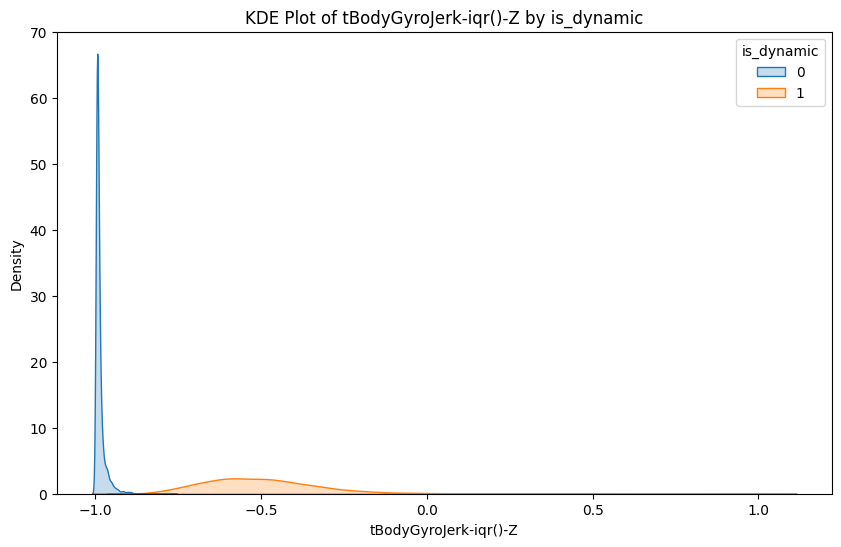

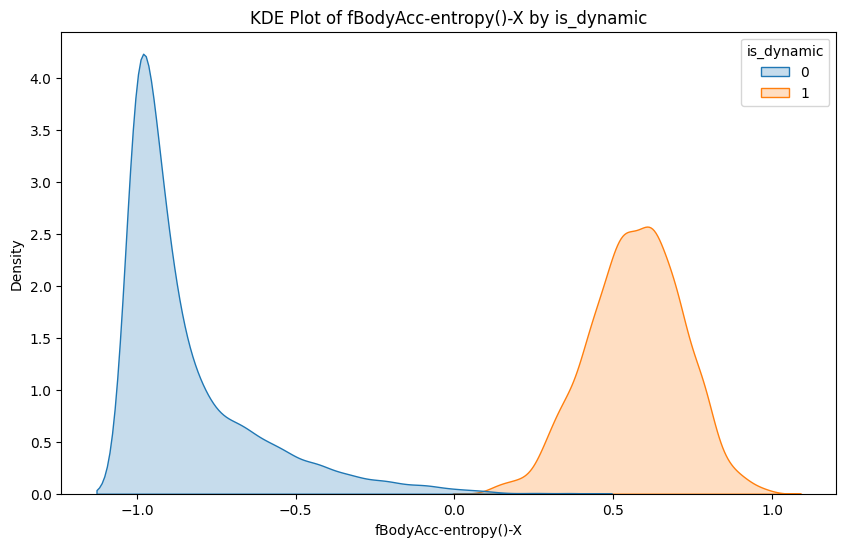

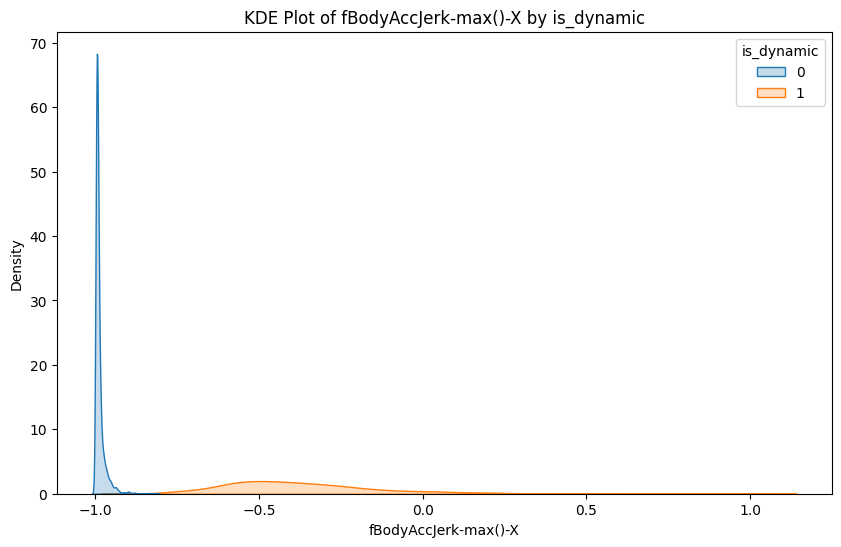

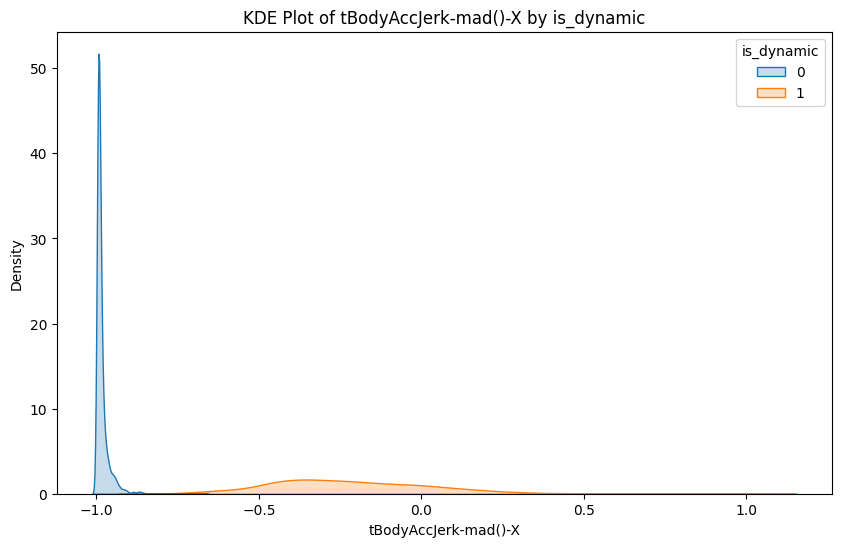

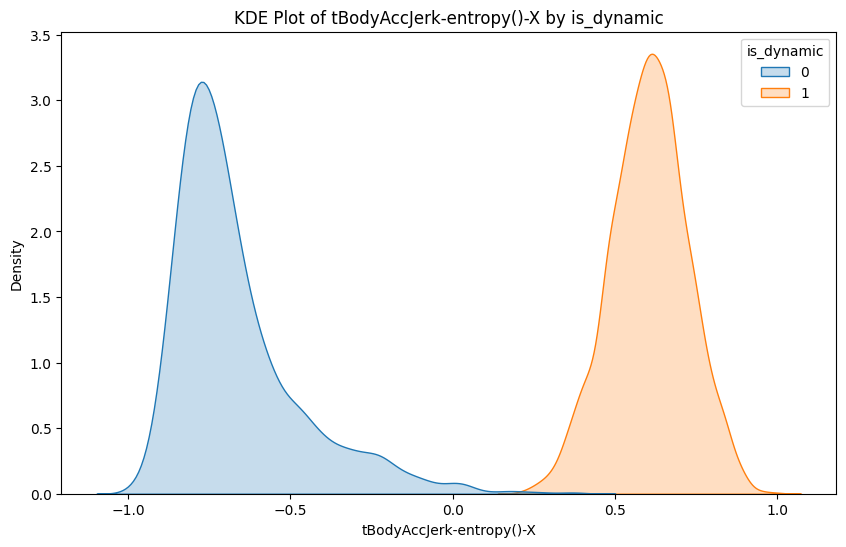

In [ ]:
# 상위 5개 변수 각각에 대해 KDE plot 그리기
top_5_dynamic_features = r_dyn['feature_name'].head(5).tolist()

for feature in top_5_dynamic_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_dynamic', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_dynamic')
    plt.show()


In [ ]:
# r_dyn에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
# r_dyn에 sensor/agg/axis 붙이기 (함수 재사용)
r_dyn[['sensor', 'agg', 'axis']] = r_dyn['feature_name'].apply(
    lambda x: pd.Series(parse_feature_name_to_components(x))
)

# sensor별 중요도 합계
sensor_importance_dyn = r_dyn.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_dyn = sensor_importance_dyn.sort_values(by='feature_importance', ascending=False)

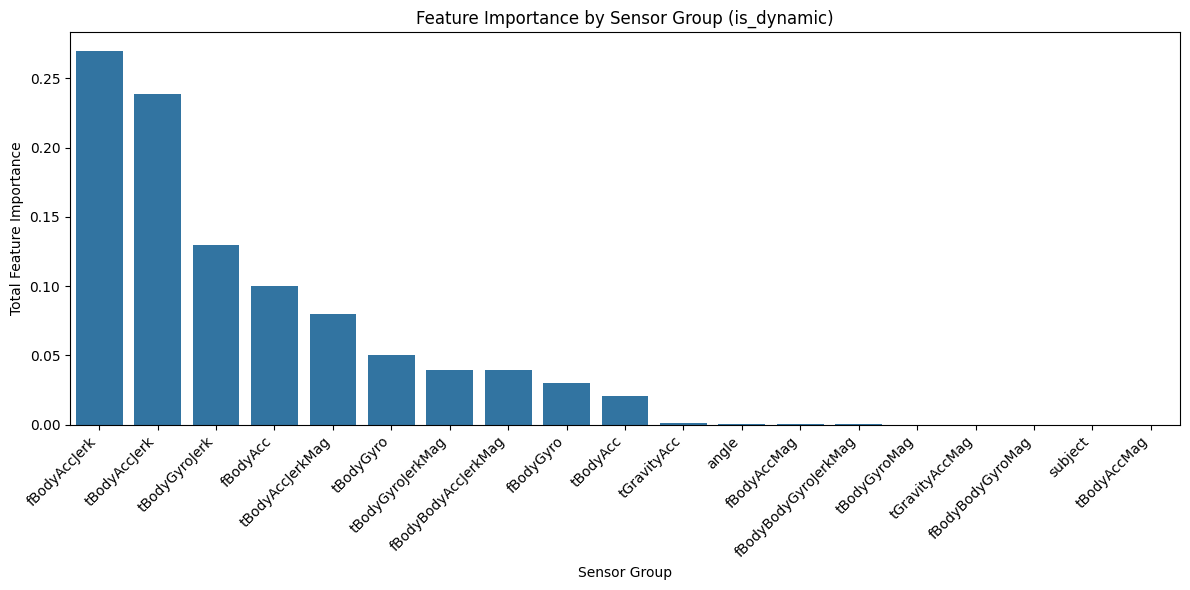

In [ ]:
# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_dyn)
plt.title('Feature Importance by Sensor Group (is_dynamic)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# sensor+agg별 중요도 합계
sensor_agg_importance_dyn = r_dyn.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_dyn = sensor_agg_importance_dyn.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_dynamic, 상위 10개):")
display(sensor_agg_importance_dyn.head(10))


Sensor + Aggregation 별 중요도 합계 (is_dynamic, 상위 10개):


,sensor,agg,feature_importance
340,tBodyGyroJerk,iqr(),0.079667
265,tBodyAccJerk,entropy(),0.069638
267,tBodyAccJerk,mad(),0.049814
50,fBodyAcc,entropy(),0.049746
109,fBodyAccJerk,max(),0.040069
345,tBodyGyroJerk,sma(),0.039840
108,fBodyAccJerk,mad(),0.039774
264,tBodyAccJerk,energy(),0.039755
68,fBodyAccJerk,"bandsEnergy()-1,8",0.029971
316,tBodyGyro,iqr(),0.029961


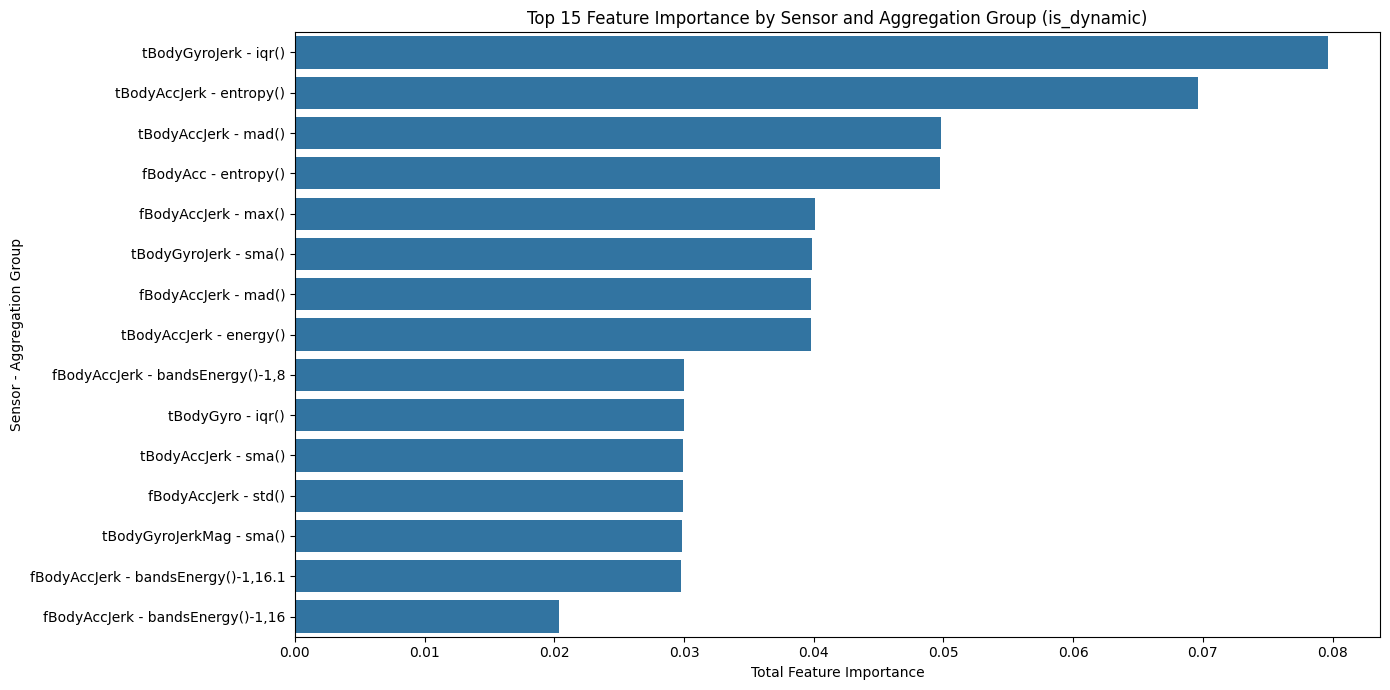

In [ ]:
# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_dyn['sensor_agg_group'] = sensor_agg_importance_dyn['sensor'] + ' - ' + sensor_agg_importance_dyn['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_dyn.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_dynamic)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()


정적(앉기/누워있기/서있기) vs 동적(걷기/계단 오르기·내리기)
이 둘을 가장 잘 구분하는 센서 + 특징(agg) 조합은?

+ Jerk + Gyro + Max/Entropy/IQR 계열

#### 데이터 가져오기로 1), 2), 3) 대체 가능

In [ ]:
#fi_analysis 데이터 불러오기
#data_path = "./fi_analysis.csv"
#fi_analysis = pd.read_csv(data_path)
#r_dyn = fi_analysis.filter(items=['feature_name','fi_all'])
#r_dyn.rename(columns={'fi_dynamic':'feature_importance'}, inplace=True)
#r_dyn.sort_values(by=['feature_importance'], axis=0, ascending=False)

### (2) 개별 동작 분석 : is_standing


* **세부 요구사항**
    - Target인 Activity를 is_standing 변수로 변경하시오.
        * 값 1 : STANDING
        * 값 0 : 나머지
    - is_standing 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_standing 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_standing 을 구분하는데 중요한 변수 상위 5개를 분석하시오. (어떤 변수가 중요한지 확인하기)
    - is_standing 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별
        * 여러가지로


In [ ]:
# 'is_standing' 컬럼 추가
data['is_standing'] = (data['Activity'] == 'STANDING').astype(int)

print("is_standing 값 분포:")
display(data['is_standing'].value_counts())
display(data.head())

is_standing 값 분포:


,count
is_standing,
0,4794
1,1087


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING,0,1
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING,0,1
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING,1,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1,0


In [ ]:
#### is_standing 기본 모델 생성

# 데이터 분할을 위한 전처리
target_standing = 'is_standing'
x_stand = data.drop(['Activity', target_standing, 'is_dynamic'], axis=1)
y_stand = data.loc[:, target_standing]

x_train_stand, x_val_stand, y_train_stand, y_val_stand = train_test_split(x_stand, y_stand, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_stand = RandomForestClassifier(random_state=42)
model_stand.fit(x_train_stand, y_train_stand)
pred_stand = model_stand.predict(x_val_stand)

# 평가
print('accuracy (is_standing) :', accuracy_score(y_val_stand, pred_stand))
print('='*60)
print(confusion_matrix(y_val_stand, pred_stand))
print('='*60)
print(classification_report(y_val_stand, pred_stand))

accuracy (is_standing) : 0.9847025495750709
[[1444    8]
 [  19  294]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1452
           1       0.97      0.94      0.96       313

    accuracy                           0.98      1765
   macro avg       0.98      0.97      0.97      1765
weighted avg       0.98      0.98      0.98      1765



is_standing 예측에 중요한 상위 5개 변수: ['tGravityAcc-max()-Y', 'angle(Y,gravityMean)', 'tGravityAcc-min()-Y', 'tGravityAcc-mean()-Y', 'angle(Z,gravityMean)']


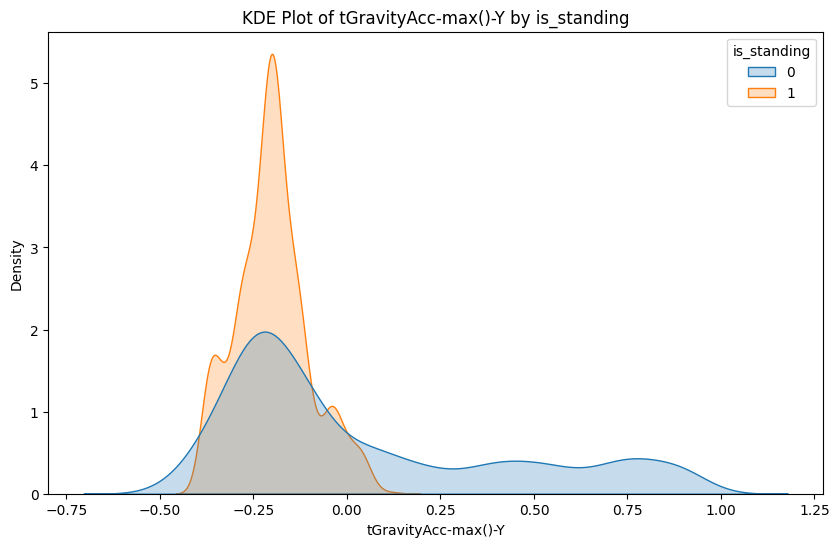

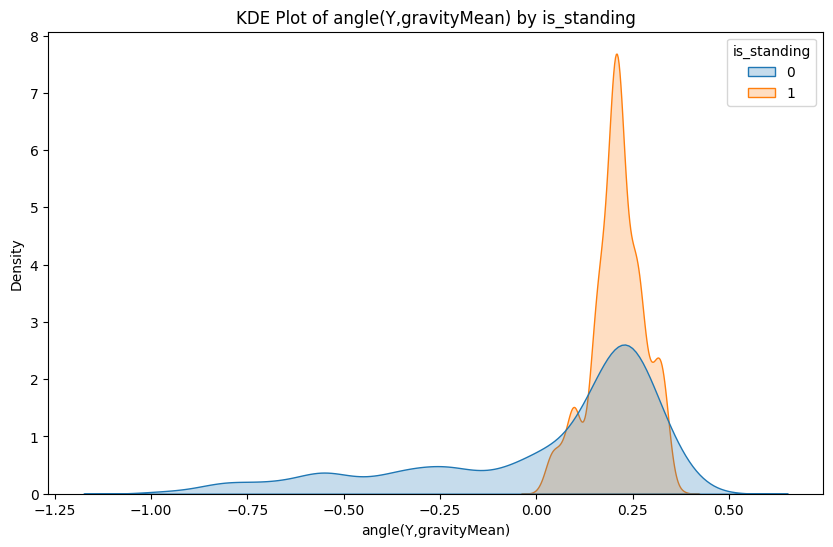

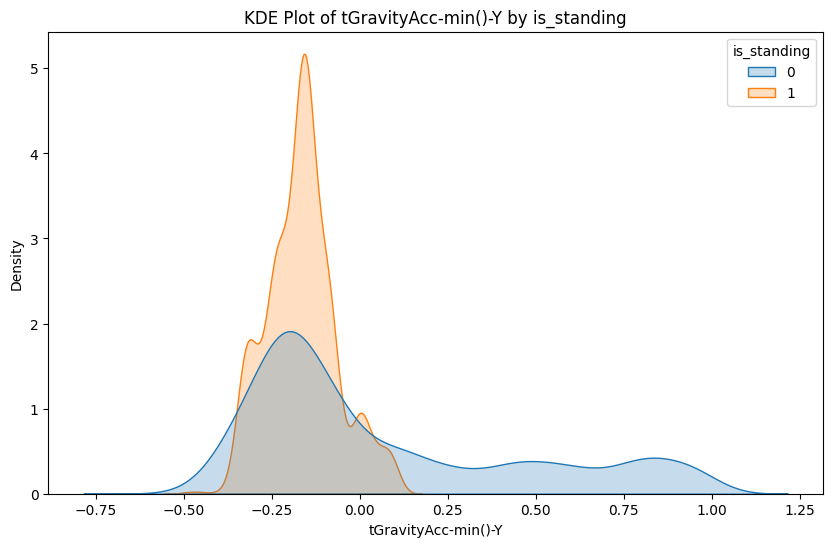

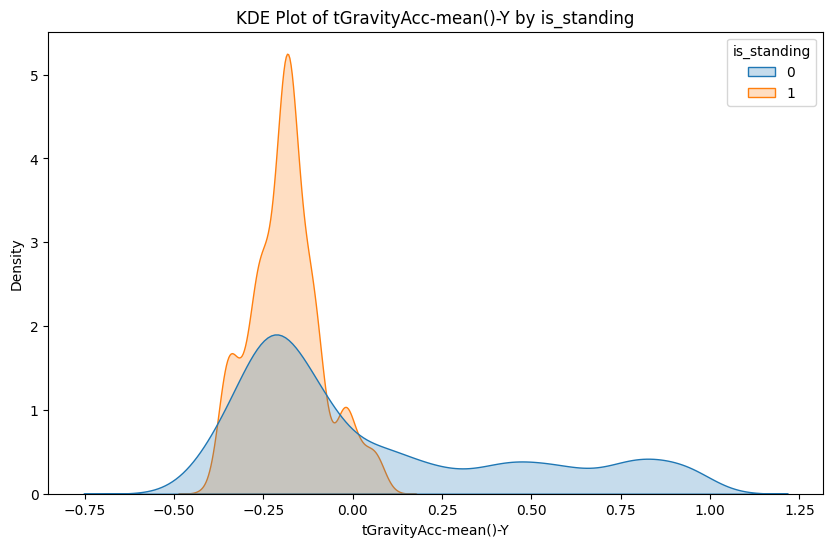

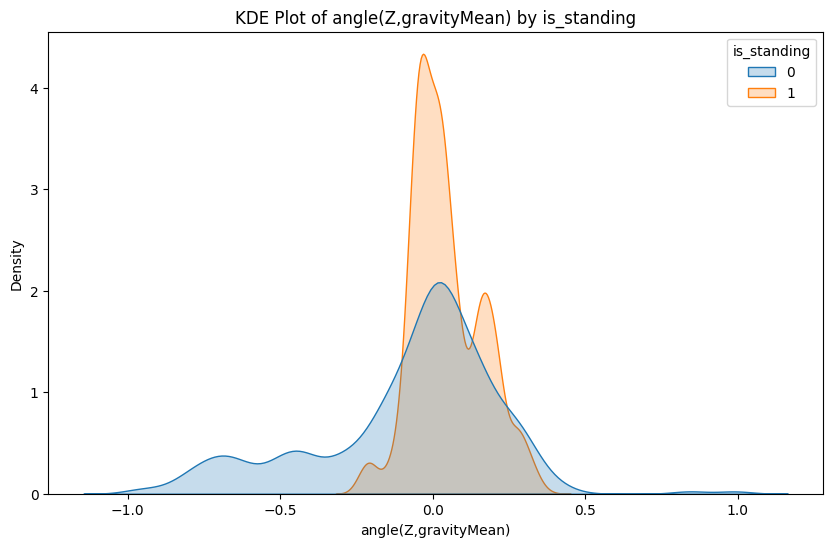

In [ ]:
#### is_standing 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_stand = plot_feature_importance(model_stand.feature_importances_, list(x_train_stand.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_stand_features = r_stand['feature_name'].head(5).tolist()
print(f"is_standing 예측에 중요한 상위 5개 변수: {top_5_stand_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_stand_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_standing', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_standing')
    plt.show()

In [ ]:
#### is_standing feature 그룹별 분석

# r_stand에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_stand[['sensor', 'agg', 'axis']] = r_stand['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_standing:")
display(r_stand.head())

Feature importance dataframe with parsed components (head) for is_standing:


,feature_name,feature_importance,sensor,agg,axis
0,tGravityAcc-max()-Y,0.070993,tGravityAcc,max(),Y
1,"angle(Y,gravityMean)",0.062431,angle,Y,gravityMean
2,tGravityAcc-min()-Y,0.056309,tGravityAcc,min(),Y
3,tGravityAcc-mean()-Y,0.046794,tGravityAcc,mean(),Y
4,"angle(Z,gravityMean)",0.028161,angle,Z,gravityMean



Sensor 별 중요도 합계 (is_standing):


,sensor,feature_importance
17,tGravityAcc,0.372424
0,angle,0.112491
1,fBodyAcc,0.102827
7,fBodyGyro,0.083280
9,tBodyAcc,0.058985
13,tBodyGyro,0.058691
12,tBodyAccMag,0.040742
14,tBodyGyroJerk,0.039228
2,fBodyAccJerk,0.033659
18,tGravityAccMag,0.029129


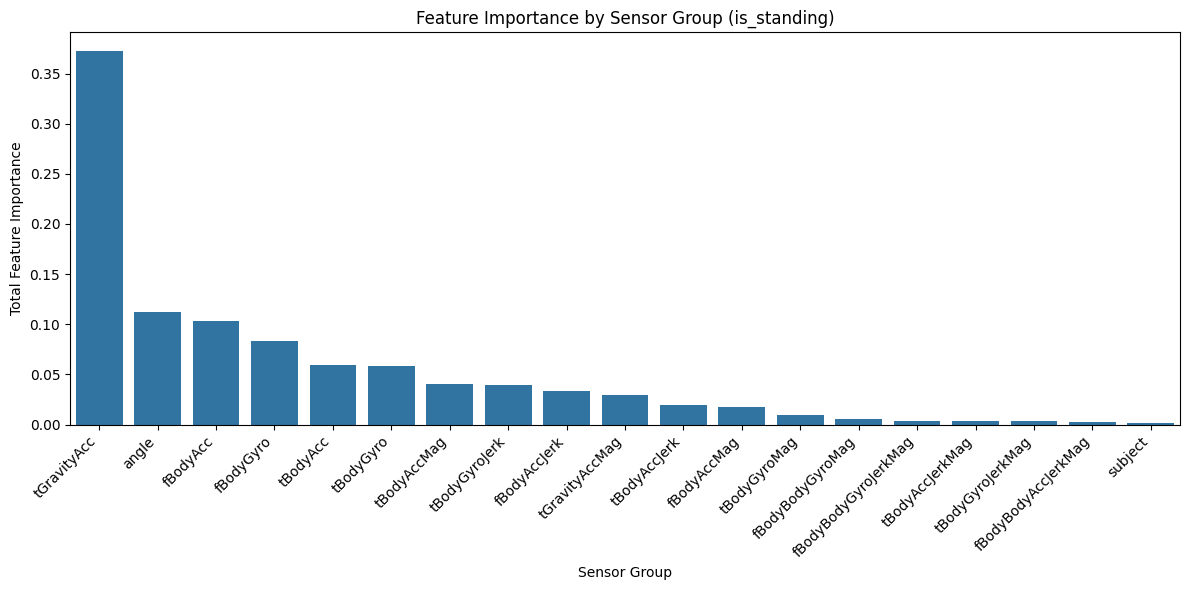

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_stand = r_stand.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_stand = sensor_importance_stand.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_standing):")
display(sensor_importance_stand)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_stand)
plt.title('Feature Importance by Sensor Group (is_standing)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_standing, 상위 10개):


,sensor,agg,feature_importance
392,tGravityAcc,max(),0.104705
393,tGravityAcc,mean(),0.087008
394,tGravityAcc,min(),0.085303
1,angle,Y,0.062431
388,tGravityAcc,energy(),0.051188
2,angle,Z,0.028161
0,angle,X,0.018559
298,tBodyAccMag,std(),0.017554
240,tBodyAcc,energy(),0.013518
59,fBodyAcc,skewness(),0.012507


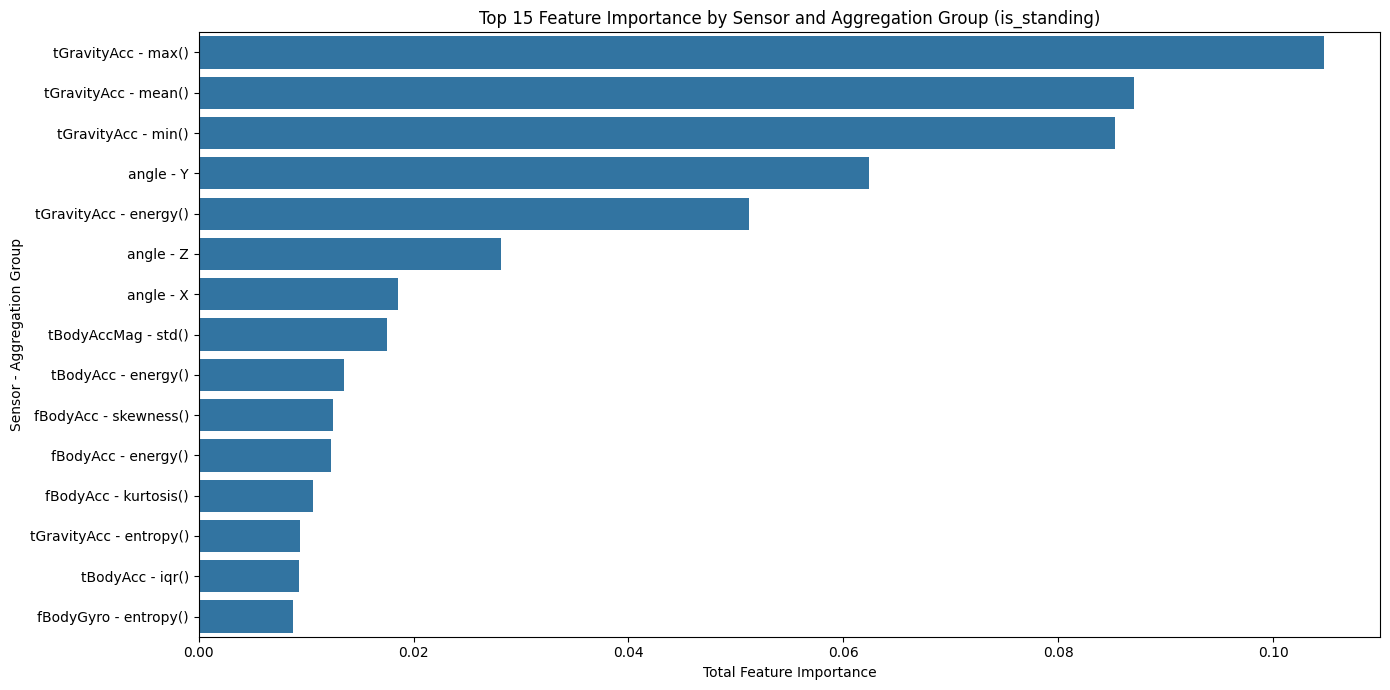

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_stand = r_stand.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_stand = sensor_agg_importance_stand.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_standing, 상위 10개):")
display(sensor_agg_importance_stand.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_stand['sensor_agg_group'] = sensor_agg_importance_stand['sensor'] + ' - ' + sensor_agg_importance_stand['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_stand.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_standing)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

### (3) 개별 동작 분석 : is_sitting


* **세부 요구사항**
    - Target인 Activity를 is_sitting 변수로 변경하시오. (이것도 컬럼을 만들기)
        * 값 1 : SITTING
        * 값 0 : 나머지 (0 나오도록)
    - is_sitting 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_sitting 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_sitting 을 구분하는데 중요한 변수 상위 5개를 분석하시오.
    - is_sitting 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별
        * 여러가지로


In [ ]:
# 'is_sitting' 컬럼 추가
data['is_sitting'] = (data['Activity'] == 'SITTING').astype(int)

print("is_sitting 값 분포:")
display(data['is_sitting'].value_counts())
display(data.head())

is_sitting 값 분포:


,count
is_sitting,
0,4849
1,1032


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING,0,1,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING,0,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING,0,1,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING,1,0,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1,0,0


In [ ]:
#### is_sitting 기본 모델 생성

# 데이터 분할을 위한 전처리
target_sitting = 'is_sitting'
x_sit = data.drop(['Activity', target_sitting, 'is_dynamic', 'is_standing'], axis=1)
y_sit = data.loc[:, target_sitting]

x_train_sit, x_val_sit, y_train_sit, y_val_sit = train_test_split(x_sit, y_sit, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_sit = RandomForestClassifier(random_state=42)
model_sit.fit(x_train_sit, y_train_sit)
pred_sit = model_sit.predict(x_val_sit)

# 평가
print('accuracy (is_sitting) :', accuracy_score(y_val_sit, pred_sit))
print('='*60)
print(confusion_matrix(y_val_sit, pred_sit))
print('='*60)
print(classification_report(y_val_sit, pred_sit))

accuracy (is_sitting) : 0.9864022662889519
[[1447    8]
 [  16  294]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1455
           1       0.97      0.95      0.96       310

    accuracy                           0.99      1765
   macro avg       0.98      0.97      0.98      1765
weighted avg       0.99      0.99      0.99      1765



is_sitting 예측에 중요한 상위 5개 변수: ['tGravityAcc-max()-Y', 'tGravityAcc-min()-Y', 'angle(Y,gravityMean)', 'tGravityAcc-mean()-Y', 'angle(X,gravityMean)']


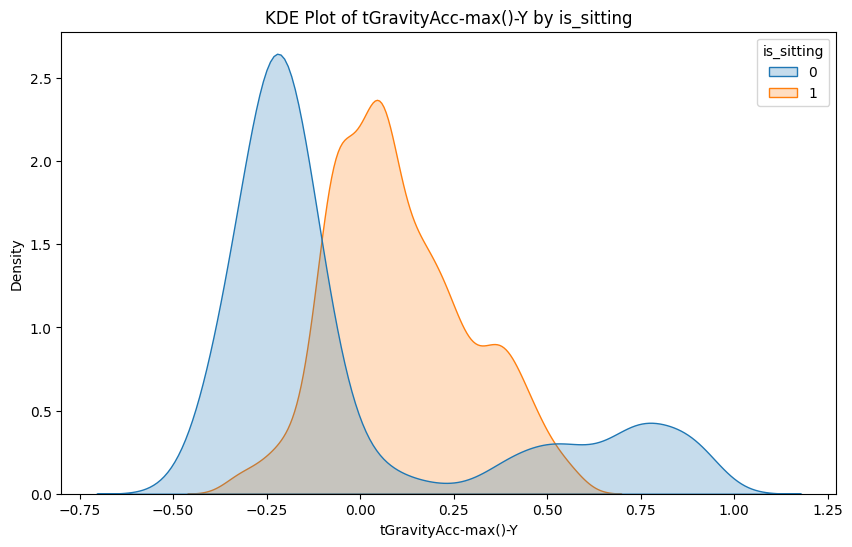

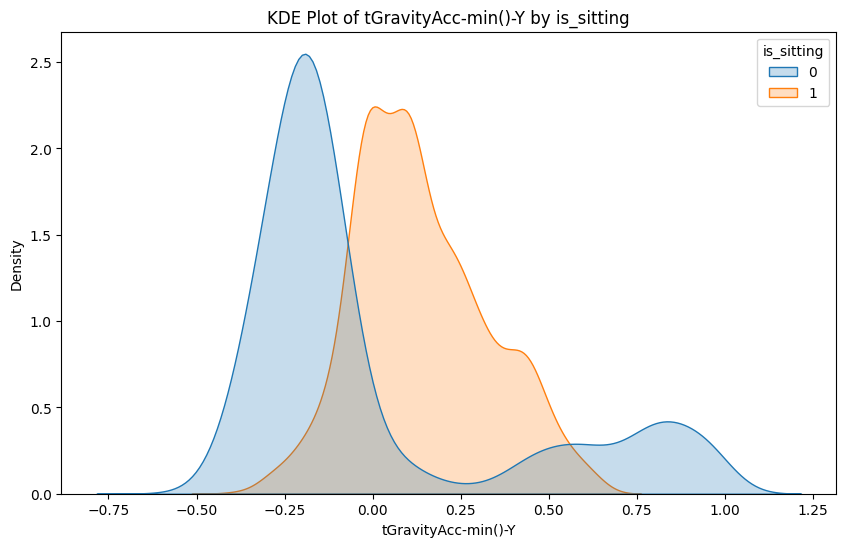

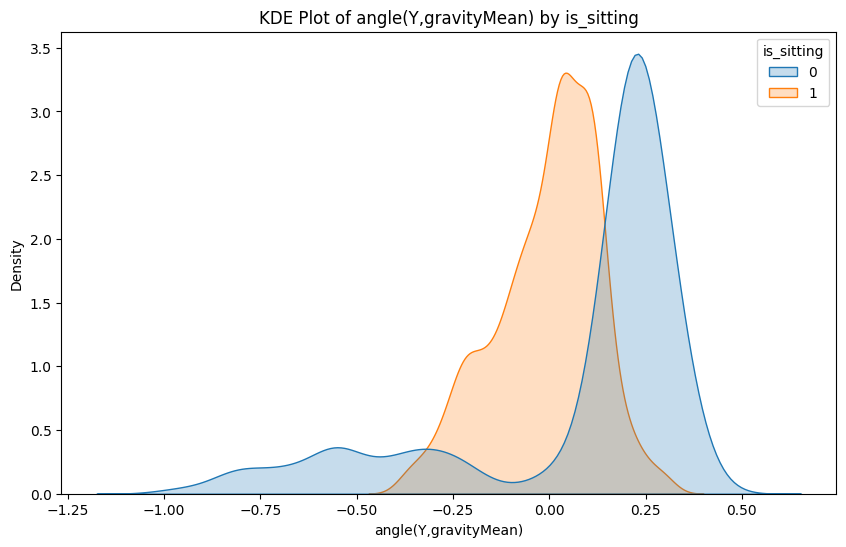

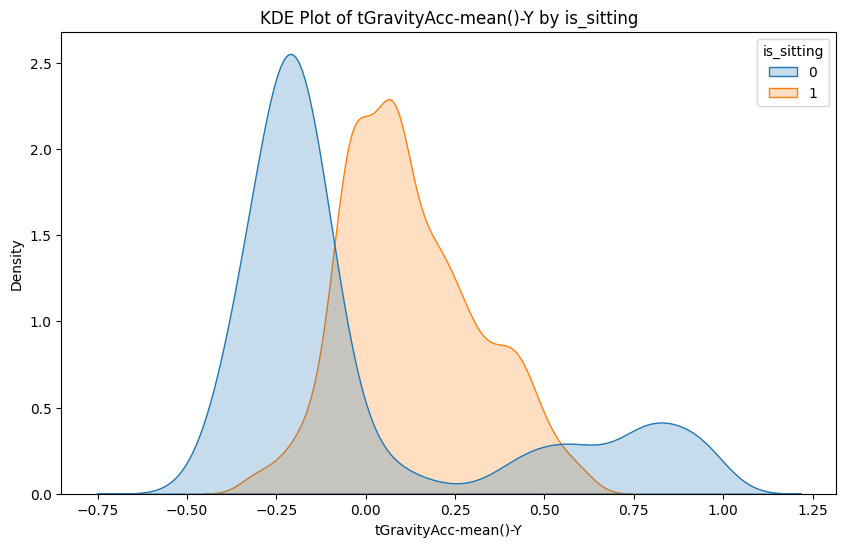

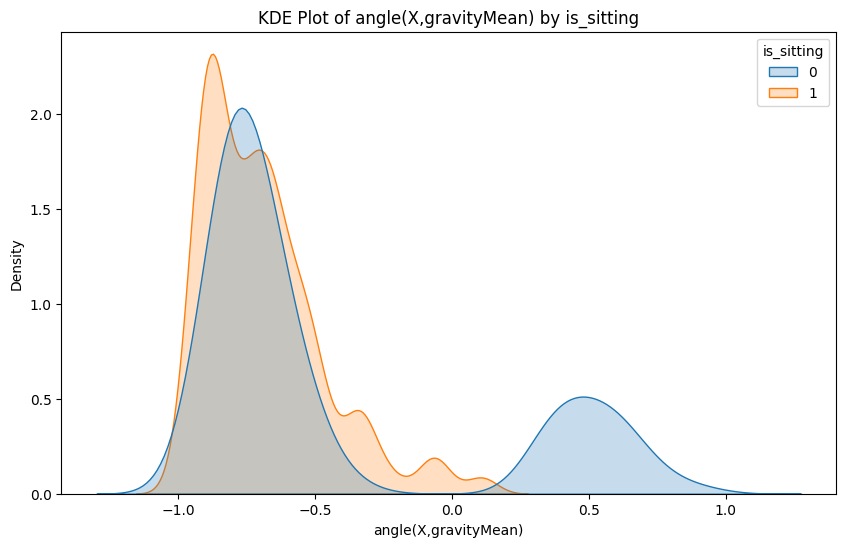

In [ ]:
#### is_sitting 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_sit = plot_feature_importance(model_sit.feature_importances_, list(x_train_sit.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_sit_features = r_sit['feature_name'].head(5).tolist()
print(f"is_sitting 예측에 중요한 상위 5개 변수: {top_5_sit_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_sit_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_sitting', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_sitting')
    plt.show()

In [ ]:
#### is_sitting feature 그룹별 분석

# r_sit에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_sit[['sensor', 'agg', 'axis']] = r_sit['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_sitting:")
display(r_sit.head())

Feature importance dataframe with parsed components (head) for is_sitting:


,feature_name,feature_importance,sensor,agg,axis
0,tGravityAcc-max()-Y,0.046273,tGravityAcc,max(),Y
1,tGravityAcc-min()-Y,0.043577,tGravityAcc,min(),Y
2,"angle(Y,gravityMean)",0.035773,angle,Y,gravityMean
3,tGravityAcc-mean()-Y,0.035422,tGravityAcc,mean(),Y
4,"angle(X,gravityMean)",0.033269,angle,X,gravityMean



Sensor 별 중요도 합계 (is_sitting):


,sensor,feature_importance
17,tGravityAcc,0.306689
7,fBodyGyro,0.222793
13,tBodyGyro,0.095351
0,angle,0.080829
1,fBodyAcc,0.066353
14,tBodyGyroJerk,0.059301
2,fBodyAccJerk,0.050552
9,tBodyAcc,0.038464
10,tBodyAccJerk,0.022750
15,tBodyGyroJerkMag,0.010747


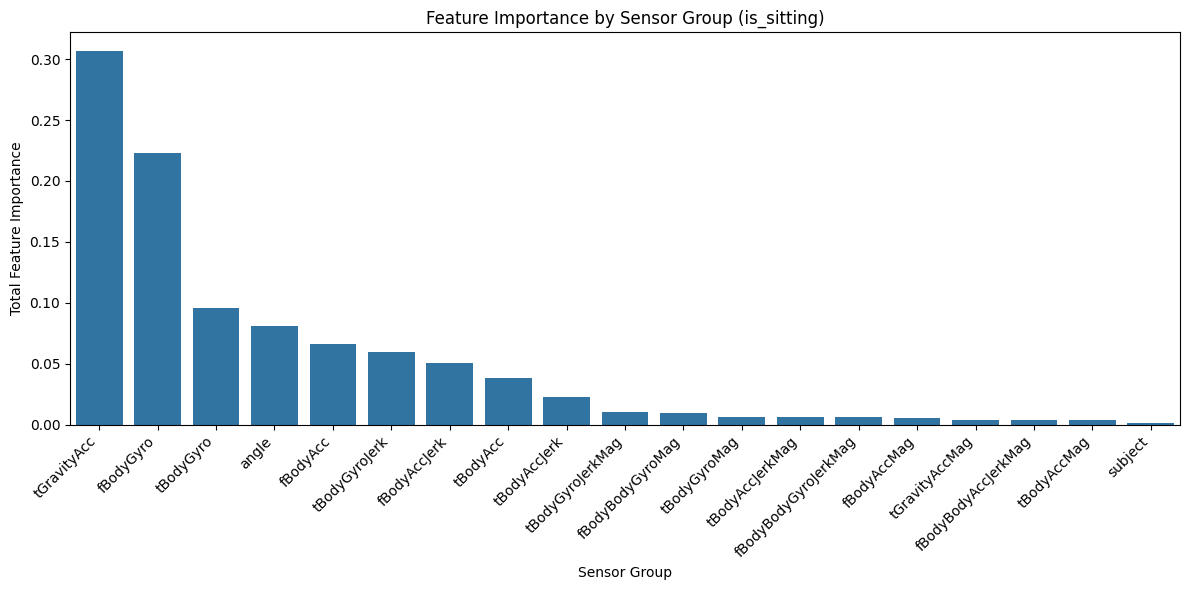

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_sit = r_sit.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_sit = sensor_importance_sit.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_sitting):")
display(sensor_importance_sit)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_sit)
plt.title('Feature Importance by Sensor Group (is_sitting)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_sitting, 상위 10개):


,sensor,agg,feature_importance
392,tGravityAcc,max(),0.077086
394,tGravityAcc,min(),0.075149
393,tGravityAcc,mean(),0.072328
388,tGravityAcc,energy(),0.042674
1,angle,Y,0.035773
0,angle,X,0.033269
317,tBodyGyro,mad(),0.018928
218,fBodyGyro,mean(),0.018919
216,fBodyGyro,max(),0.017433
322,tBodyGyro,std(),0.017373


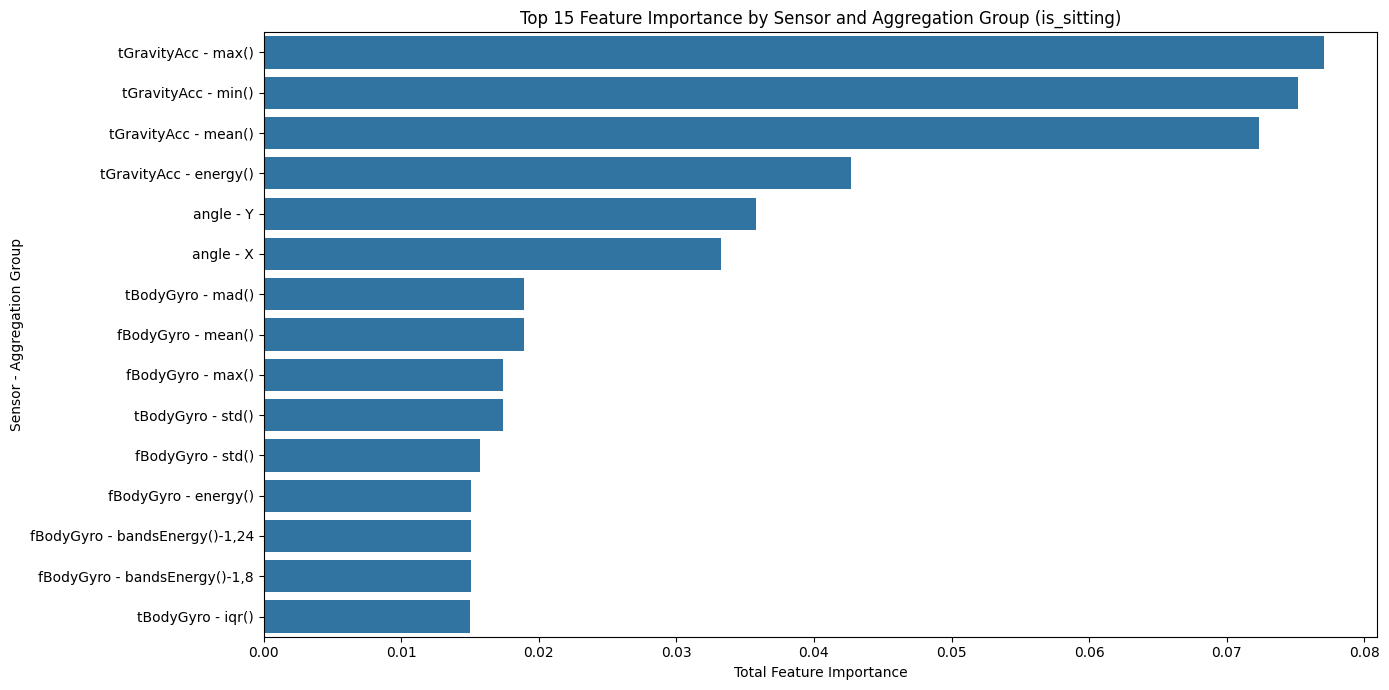

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_sit = r_sit.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_sit = sensor_agg_importance_sit.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_sitting, 상위 10개):")
display(sensor_agg_importance_sit.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_sit['sensor_agg_group'] = sensor_agg_importance_sit['sensor'] + ' - ' + sensor_agg_importance_sit['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_sit.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_sitting)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

### (4) 개별 동작 분석 : is_laying


* **세부 요구사항**
    - Target인 Activity를 is_laying 변수로 변경하시오.
        * 값 1 : LAYING
        * 값 0 : 나머지
    - is_laying 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_laying 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_laying 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_laying 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


In [ ]:
# 'is_laying' 컬럼 추가
data['is_laying'] = (data['Activity'] == 'LAYING').astype(int)

print("is_laying 값 분포:")
display(data['is_laying'].value_counts())
display(data.head())

is_laying 값 분포:


,count
is_laying,
0,4766
1,1115


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.072790,-0.601120,0.331298,0.165163,21,STANDING,0,1,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,0.771524,0.345205,-0.769186,-0.147944,15,LAYING,0,0,0,1
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,0.021528,-0.833564,0.202434,-0.032755,11,STANDING,0,1,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.072944,-0.695819,0.287154,0.111388,17,WALKING,1,0,0,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0


In [ ]:
#### is_laying 기본 모델 생성

# 데이터 분할을 위한 전처리
target_laying = 'is_laying'
x_lay = data.drop(['Activity', target_laying, 'is_dynamic', 'is_standing', 'is_sitting'], axis=1)
y_lay = data.loc[:, target_laying]

x_train_lay, x_val_lay, y_train_lay, y_val_lay = train_test_split(x_lay, y_lay, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_lay = RandomForestClassifier(random_state=42)
model_lay.fit(x_train_lay, y_train_lay)
pred_lay = model_lay.predict(x_val_lay)

# 평가
print('accuracy (is_laying) :', accuracy_score(y_val_lay, pred_lay))
print('='*60)
print(confusion_matrix(y_val_lay, pred_lay))
print('='*60)
print(classification_report(y_val_lay, pred_lay))

accuracy (is_laying) : 1.0
[[1431    0]
 [   0  334]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1431
           1       1.00      1.00      1.00       334

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765



is_laying 예측에 중요한 상위 5개 변수: ['tGravityAcc-mean()-X', 'tGravityAcc-max()-X', 'tGravityAcc-energy()-X', 'angle(X,gravityMean)', 'tGravityAcc-min()-X']


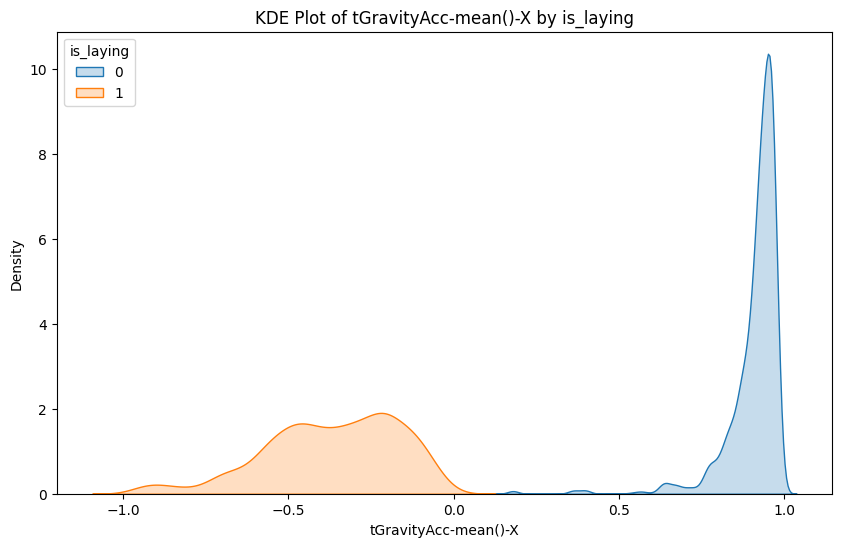

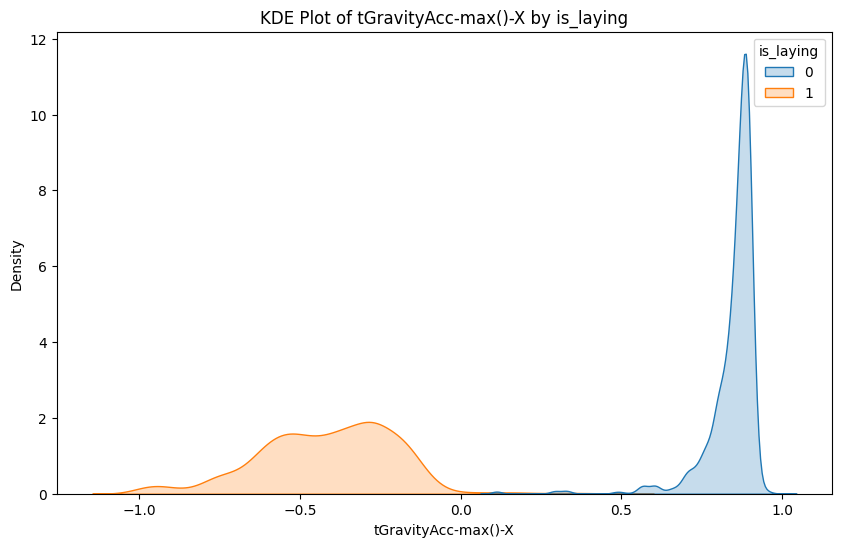

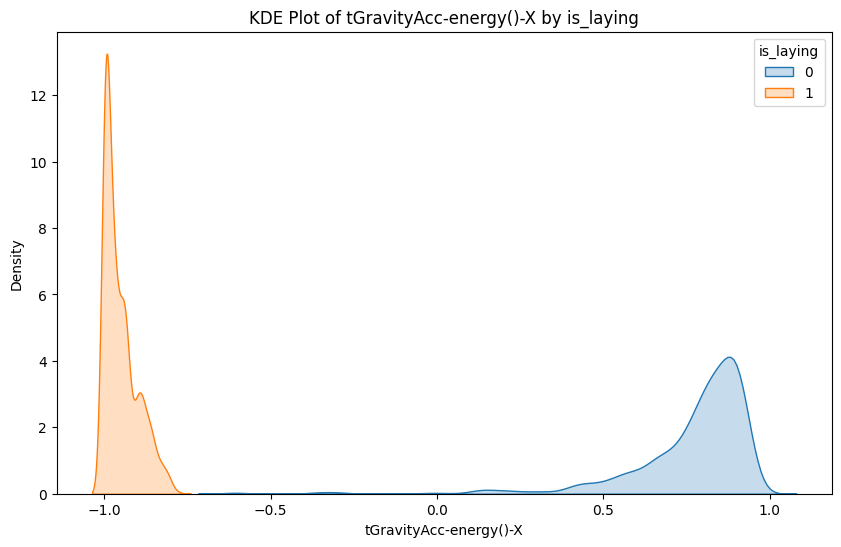

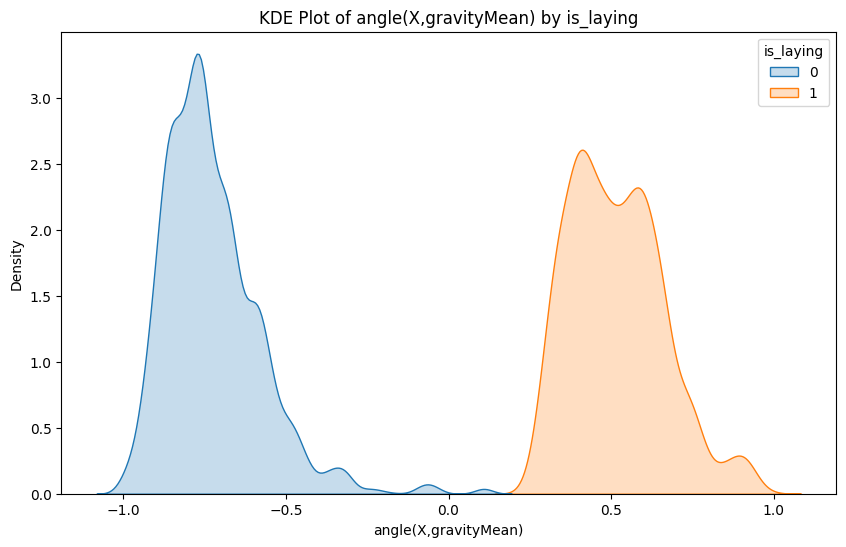

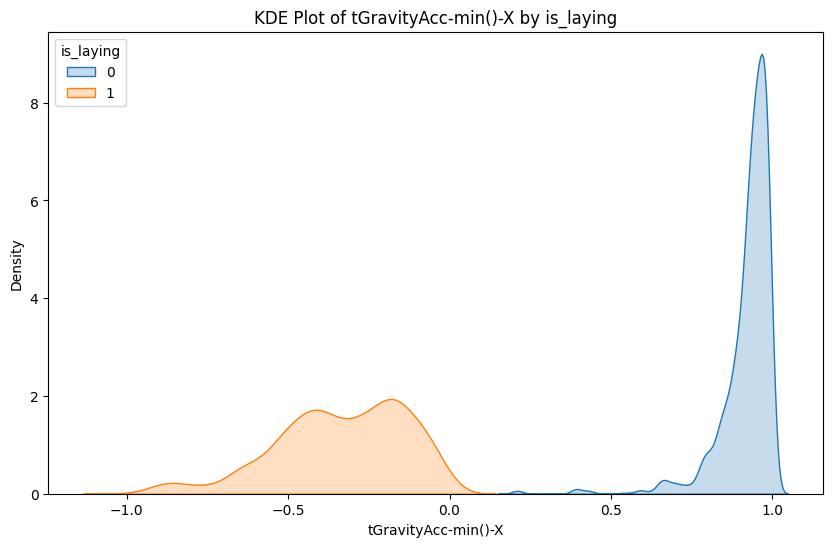

In [ ]:
#### is_laying 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_lay = plot_feature_importance(model_lay.feature_importances_, list(x_train_lay.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_lay_features = r_lay['feature_name'].head(5).tolist()
print(f"is_laying 예측에 중요한 상위 5개 변수: {top_5_lay_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_lay_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_laying', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_laying')
    plt.show()

In [ ]:
#### is_laying feature 그룹별 분석

# r_lay에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_lay[['sensor', 'agg', 'axis']] = r_lay['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_laying:")
display(r_lay.head())

Feature importance dataframe with parsed components (head) for is_laying:


,feature_name,feature_importance,sensor,agg,axis
0,tGravityAcc-mean()-X,0.106174,tGravityAcc,mean(),X
1,tGravityAcc-max()-X,0.105865,tGravityAcc,max(),X
2,tGravityAcc-energy()-X,0.074969,tGravityAcc,energy(),X
3,"angle(X,gravityMean)",0.063431,angle,X,gravityMean
4,tGravityAcc-min()-X,0.062329,tGravityAcc,min(),X



Sensor 별 중요도 합계 (is_laying):


,sensor,feature_importance
17,tGravityAcc,0.650752
0,angle,0.151551
7,fBodyGyro,0.035349
13,tBodyGyro,0.035004
1,fBodyAcc,0.031714
2,fBodyAccJerk,0.027476
9,tBodyAcc,0.022370
14,tBodyGyroJerk,0.016212
10,tBodyAccJerk,0.011375
11,tBodyAccJerkMag,0.005786


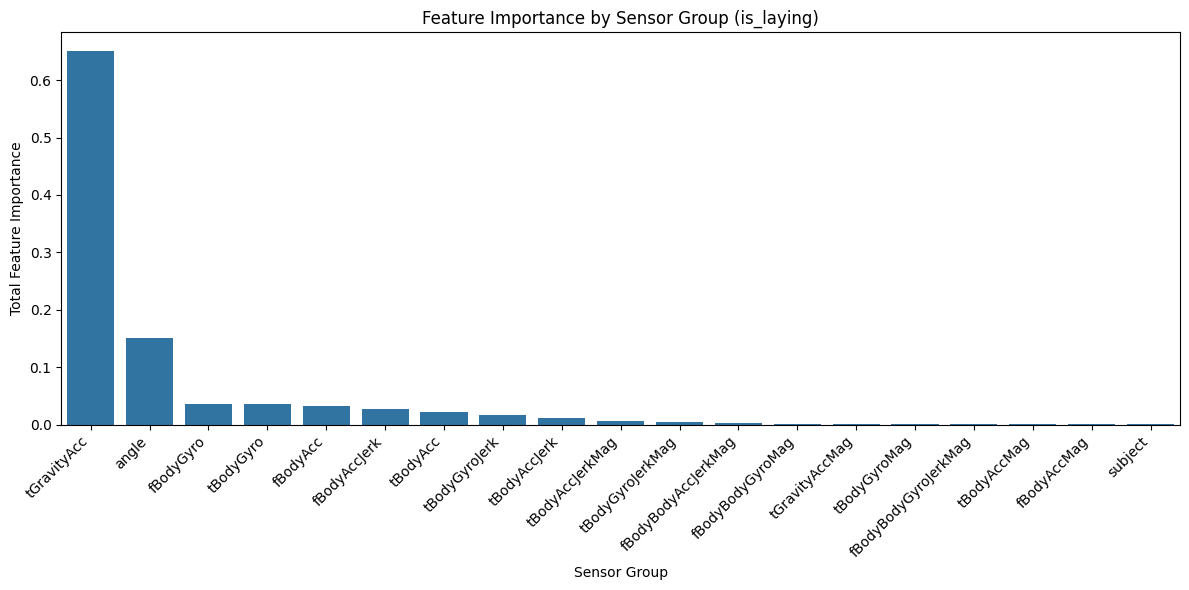

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_lay = r_lay.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_lay = sensor_importance_lay.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_laying):")
display(sensor_importance_lay)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_lay)
plt.title('Feature Importance by Sensor Group (is_laying)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_laying, 상위 10개):


,sensor,agg,feature_importance
392,tGravityAcc,max(),0.171859
393,tGravityAcc,mean(),0.171386
388,tGravityAcc,energy(),0.160372
394,tGravityAcc,min(),0.108949
0,angle,X,0.063431
1,angle,Y,0.053630
2,angle,Z,0.034186
239,tBodyAcc,"correlation()-Y,Z",0.010414
387,tGravityAcc,"correlation()-Y,Z",0.009442
322,tBodyGyro,std(),0.008333


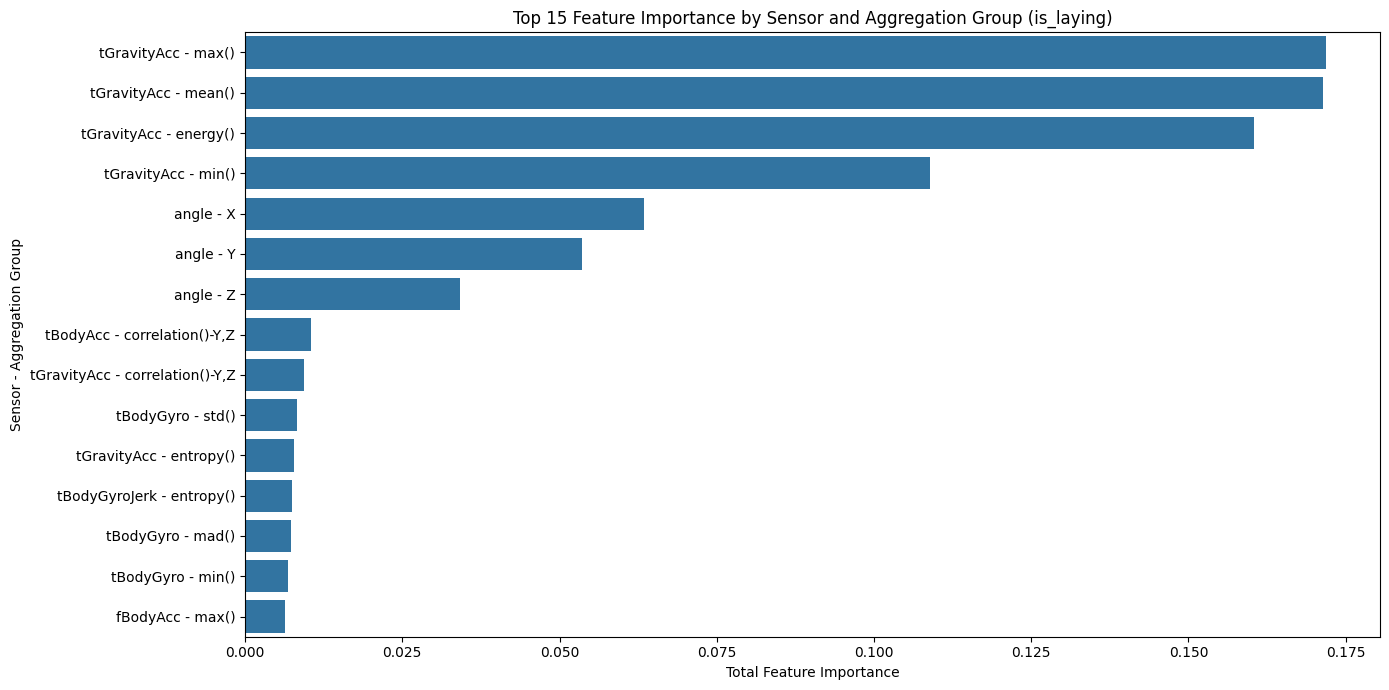

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_lay = r_lay.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_lay = sensor_agg_importance_lay.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_laying, 상위 10개):")
display(sensor_agg_importance_lay.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_lay['sensor_agg_group'] = sensor_agg_importance_lay['sensor'] + ' - ' + sensor_agg_importance_lay['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_lay.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_laying)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

### (5) 개별 동작 분석 : is_walking


* **세부 요구사항**
    - Target인 Activity를 is_walking 변수로 변경하시오.
        * 값 1 : WALKING
        * 값 0 : 나머지
    - is_walking 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_walking 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_walking 을 구분하는데 중요한 변수 상위 5개를 분석하시오.
    - is_walking 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


In [ ]:
# 'is_walking' 컬럼 추가
data['is_walking'] = (data['Activity'] == 'WALKING').astype(int)

print("is_walking 값 분포:")
display(data['is_walking'].value_counts())
display(data.head())

is_walking 값 분포:


,count
is_walking,
0,4883
1,998


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying,is_walking
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.601120,0.331298,0.165163,21,STANDING,0,1,0,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,0.345205,-0.769186,-0.147944,15,LAYING,0,0,0,1,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.833564,0.202434,-0.032755,11,STANDING,0,1,0,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.695819,0.287154,0.111388,17,WALKING,1,0,0,0,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0,0


In [ ]:
#### is_walking 기본 모델 생성

# 데이터 분할을 위한 전처리
target_walking = 'is_walking'
x_walk = data.drop(['Activity', target_walking, 'is_dynamic', 'is_standing', 'is_sitting', 'is_laying'], axis=1)
y_walk = data.loc[:, target_walking]

x_train_walk, x_val_walk, y_train_walk, y_val_walk = train_test_split(x_walk, y_walk, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_walk = RandomForestClassifier(random_state=42)
model_walk.fit(x_train_walk, y_train_walk)
pred_walk = model_walk.predict(x_val_walk)

# 평가
print('accuracy (is_walking) :', accuracy_score(y_val_walk, pred_walk))
print('='*60)
print(confusion_matrix(y_val_walk, pred_walk))
print('='*60)
print(classification_report(y_val_walk, pred_walk))

accuracy (is_walking) : 0.996600566572238
[[1473    0]
 [   6  286]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1473
           1       1.00      0.98      0.99       292

    accuracy                           1.00      1765
   macro avg       1.00      0.99      0.99      1765
weighted avg       1.00      1.00      1.00      1765



is_walking 예측에 중요한 상위 5개 변수: ['fBodyAccMag-std()', 'tBodyAccMag-arCoeff()1', 'tGravityAcc-arCoeff()-X,1', 'fBodyAcc-max()-X', 'fBodyAccMag-max()']


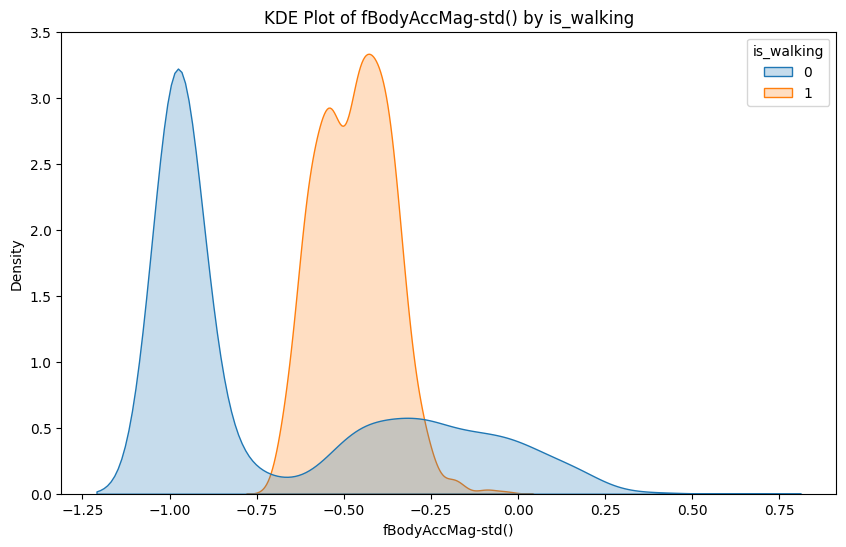

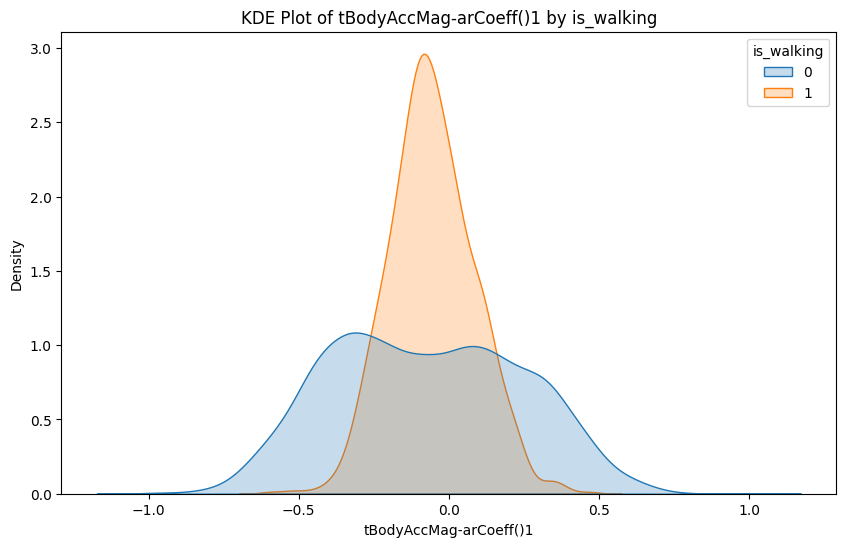

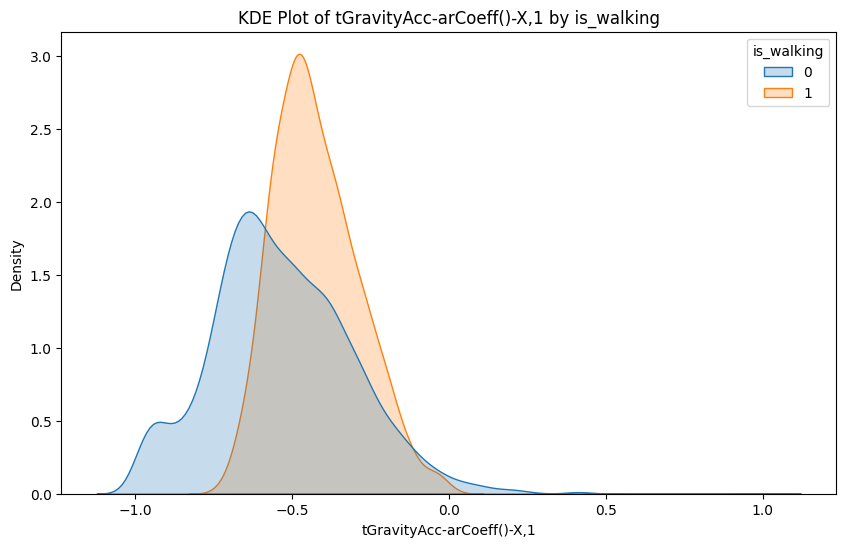

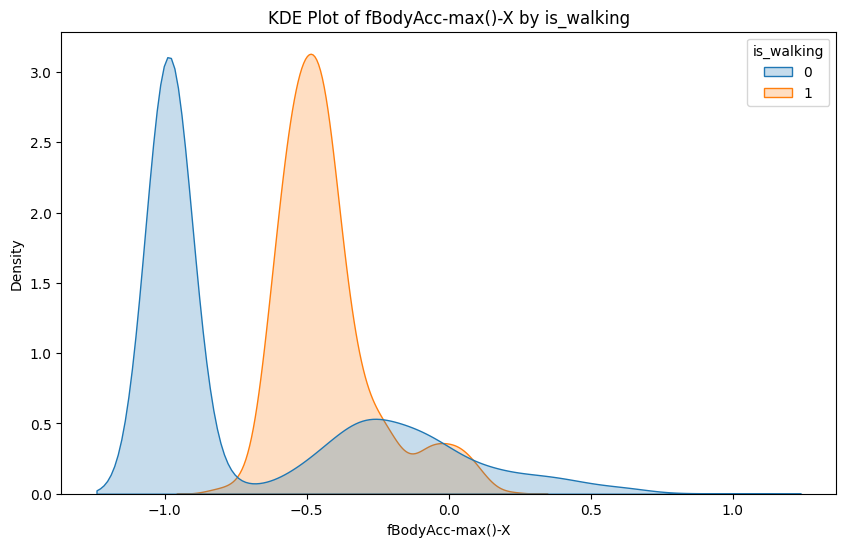

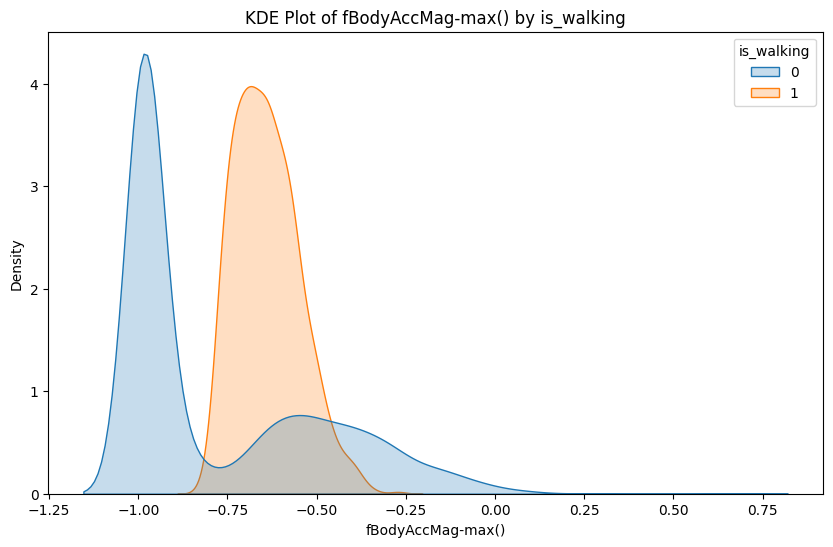

In [ ]:
#### is_walking 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_walk = plot_feature_importance(model_walk.feature_importances_, list(x_train_walk.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_walk_features = r_walk['feature_name'].head(5).tolist()
print(f"is_walking 예측에 중요한 상위 5개 변수: {top_5_walk_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_walk_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_walking', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_walking')
    plt.show()

In [ ]:
#### is_walking feature 그룹별 분석

# r_walk에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_walk[['sensor', 'agg', 'axis']] = r_walk['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_walking:")
display(r_walk.head())

Feature importance dataframe with parsed components (head) for is_walking:


,feature_name,feature_importance,sensor,agg,axis
0,fBodyAccMag-std(),0.033961,fBodyAccMag,std(),None
1,tBodyAccMag-arCoeff()1,0.021750,tBodyAccMag,arCoeff()1,None
2,"tGravityAcc-arCoeff()-X,1",0.021510,tGravityAcc,"arCoeff()-X,1",None
3,fBodyAcc-max()-X,0.019156,fBodyAcc,max(),X
4,fBodyAccMag-max(),0.017873,fBodyAccMag,max(),None



Sensor 별 중요도 합계 (is_walking):


,sensor,feature_importance
17,tGravityAcc,0.167855
1,fBodyAcc,0.121944
2,fBodyAccJerk,0.108590
3,fBodyAccMag,0.098383
14,tBodyGyroJerk,0.090376
12,tBodyAccMag,0.067656
18,tGravityAccMag,0.066490
10,tBodyAccJerk,0.059351
9,tBodyAcc,0.051960
7,fBodyGyro,0.044894


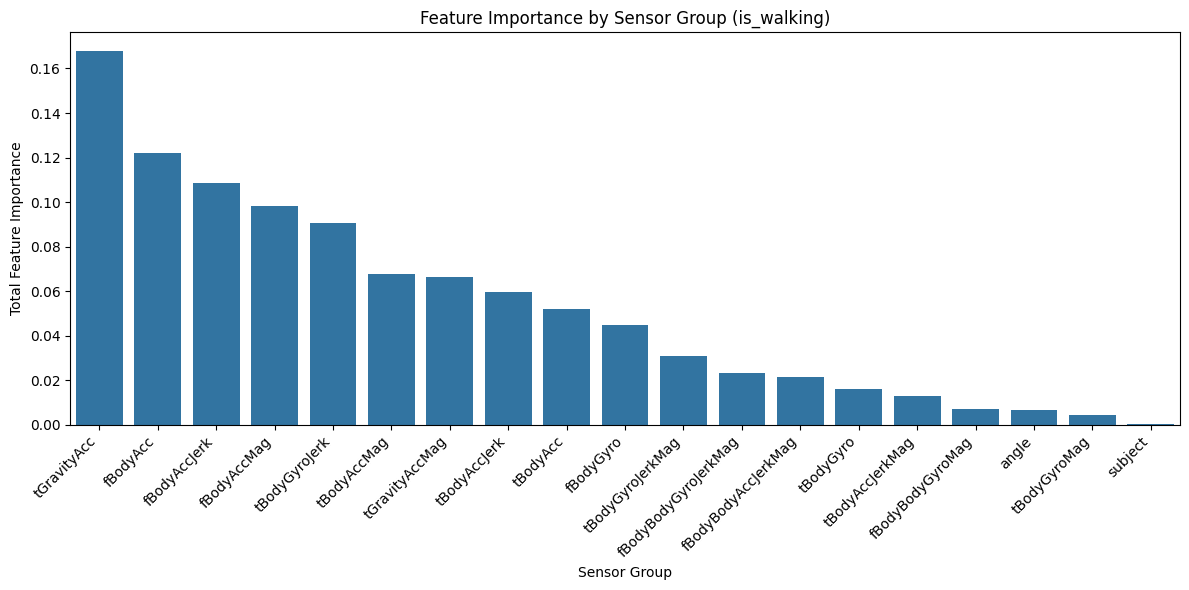

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_walk = r_walk.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_walk = sensor_importance_walk.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_walking):")
display(sensor_importance_walk)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_walk)
plt.title('Feature Importance by Sensor Group (is_walking)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_walking, 상위 10개):


,sensor,agg,feature_importance
129,fBodyAccMag,std(),0.033961
286,tBodyAccMag,arCoeff()1,0.021750
373,tGravityAcc,"arCoeff()-X,1",0.021510
54,fBodyAcc,max(),0.020786
341,tBodyGyroJerk,mad(),0.019970
346,tBodyGyroJerk,std(),0.018009
122,fBodyAccMag,max(),0.017873
268,tBodyAccJerk,max(),0.016461
293,tBodyAccMag,mad(),0.016425
237,tBodyAcc,"correlation()-X,Y",0.016423


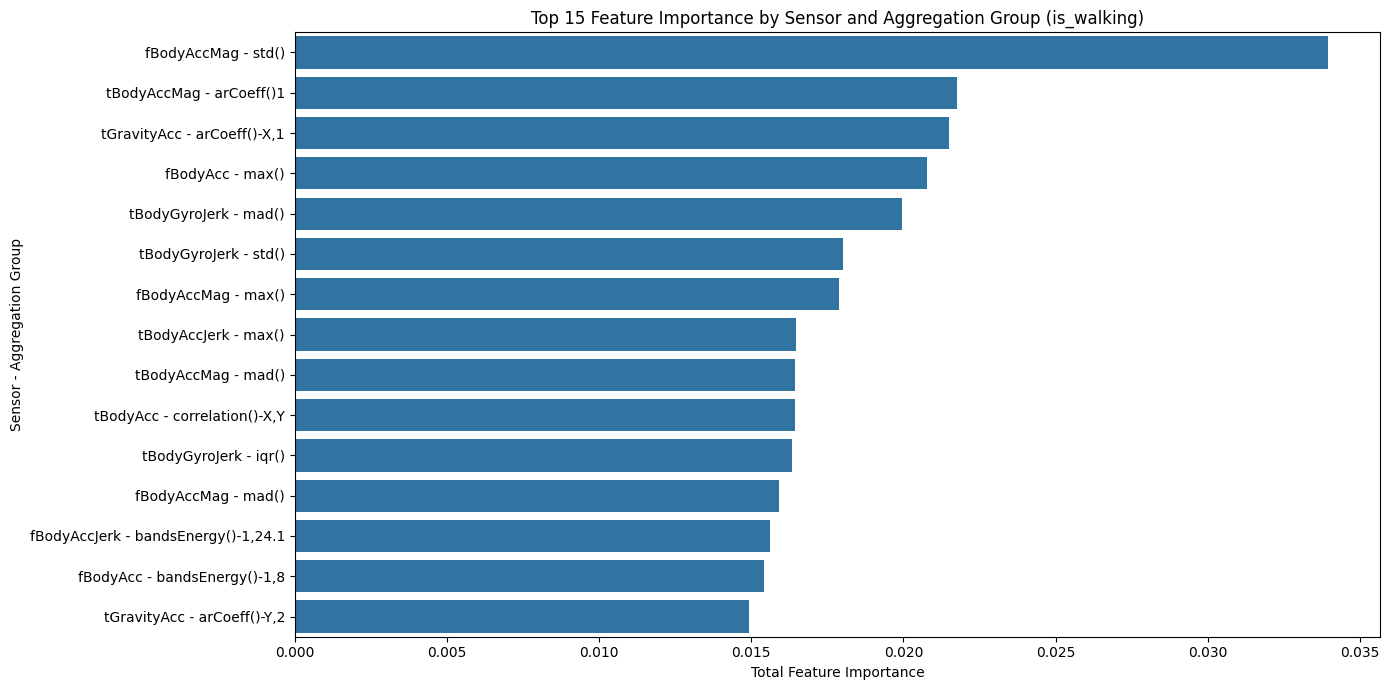

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_walk = r_walk.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_walk = sensor_agg_importance_walk.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_walking, 상위 10개):")
display(sensor_agg_importance_walk.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_walk['sensor_agg_group'] = sensor_agg_importance_walk['sensor'] + ' - ' + sensor_agg_importance_walk['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_walk.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_walking)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

### (6) 개별 동작 분석 : is_walking_up


* **세부 요구사항**
    - Target인 Activity를 is_walking_up 변수로 변경하시오.
        * 값 1 : WALKING_UPSTAIRS
        * 값 0 : 나머지
    - is_walking_up 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_walking_up 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_walking_up 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_walking_up 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


In [ ]:
# 'is_walking_up' 컬럼 추가
data['is_walking_up'] = (data['Activity'] == 'WALKING_UPSTAIRS').astype(int)

print("is_walking_up 값 분포:")
display(data['is_walking_up'].value_counts())
display(data.head())

is_walking_up 값 분포:


,count
is_walking_up,
0,5023
1,858


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying,is_walking,is_walking_up
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.331298,0.165163,21,STANDING,0,1,0,0,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.769186,-0.147944,15,LAYING,0,0,0,1,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,0.202434,-0.032755,11,STANDING,0,1,0,0,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.287154,0.111388,17,WALKING,1,0,0,0,1,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,0.264952,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0,0,0


In [ ]:
#### is_walking_up 기본 모델 생성

# 데이터 분할을 위한 전처리
target_walking_up = 'is_walking_up'
x_walk_up = data.drop(['Activity', target_walking_up, 'is_dynamic', 'is_standing', 'is_sitting', 'is_laying', 'is_walking'], axis=1)
y_walk_up = data.loc[:, target_walking_up]

x_train_walk_up, x_val_walk_up, y_train_walk_up, y_val_walk_up = train_test_split(x_walk_up, y_walk_up, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_walk_up = RandomForestClassifier(random_state=42)
model_walk_up.fit(x_train_walk_up, y_train_walk_up)
pred_walk_up = model_walk_up.predict(x_val_walk_up)

# 평가
print('accuracy (is_walking_up) :', accuracy_score(y_val_walk_up, pred_walk_up))
print('='*60)
print(confusion_matrix(y_val_walk_up, pred_walk_up))
print('='*60)
print(classification_report(y_val_walk_up, pred_walk_up))

accuracy (is_walking_up) : 0.9943342776203966
[[1485    3]
 [   7  270]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1488
           1       0.99      0.97      0.98       277

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



is_walking_up 예측에 중요한 상위 5개 변수: ['tGravityAcc-min()-Y', 'tGravityAcc-arCoeff()-Z,1', 'tGravityAcc-arCoeff()-Z,2', 'tGravityAcc-arCoeff()-Y,1', 'fBodyGyro-maxInds-Z']


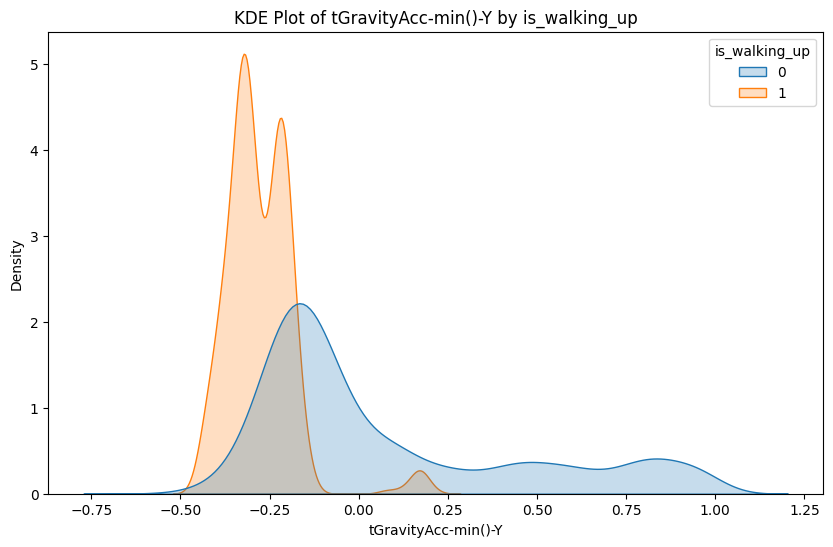

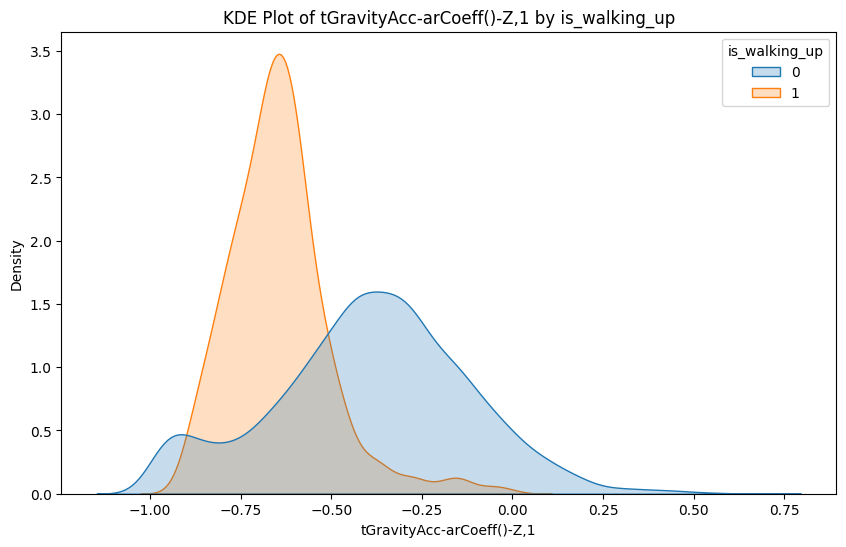

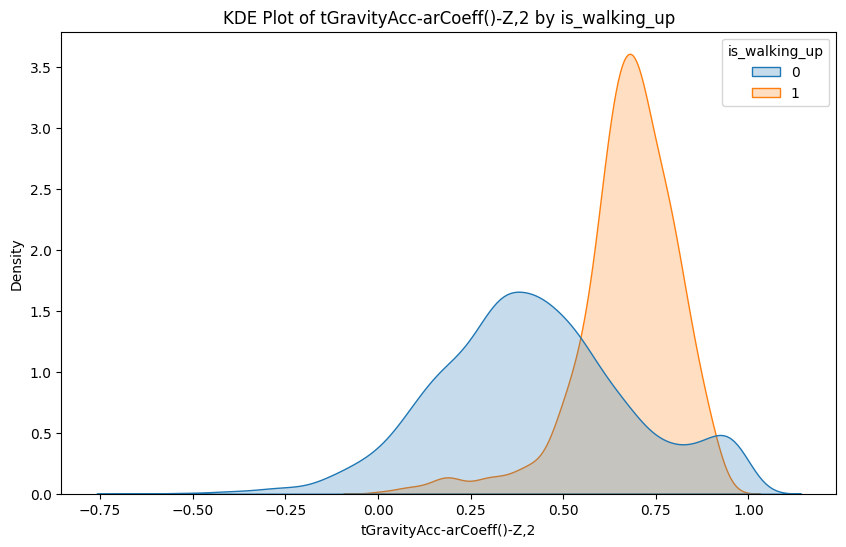

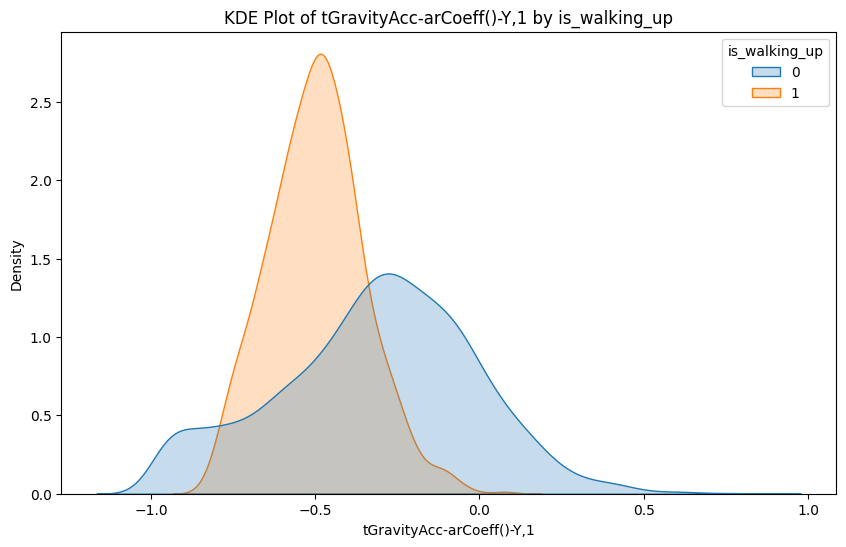

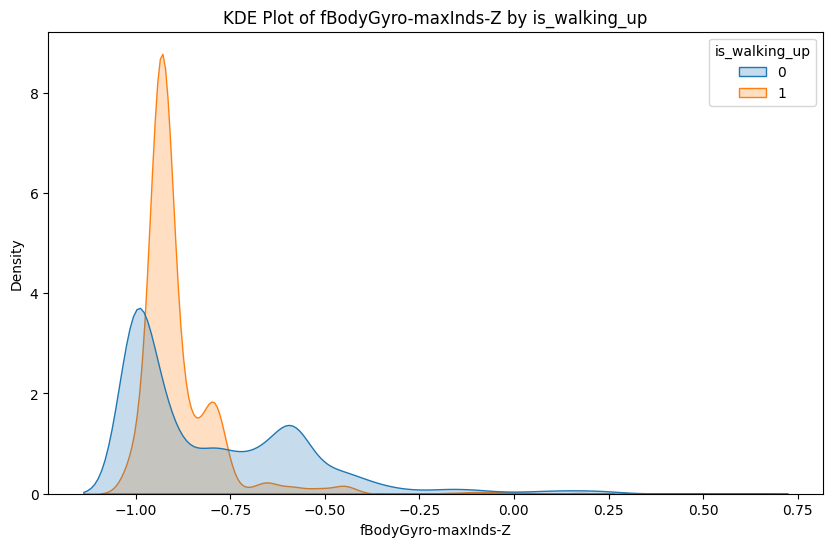

In [ ]:
#### is_walking_up 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_walk_up = plot_feature_importance(model_walk_up.feature_importances_, list(x_train_walk_up.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_walk_up_features = r_walk_up['feature_name'].head(5).tolist()
print(f"is_walking_up 예측에 중요한 상위 5개 변수: {top_5_walk_up_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_walk_up_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_walking_up', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_walking_up')
    plt.show()

In [ ]:
#### is_walking_up feature 그룹별 분석

# r_walk_up에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_walk_up[['sensor', 'agg', 'axis']] = r_walk_up['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_walking_up:")
display(r_walk_up.head())

Feature importance dataframe with parsed components (head) for is_walking_up:


,feature_name,feature_importance,sensor,agg,axis
0,tGravityAcc-min()-Y,0.031524,tGravityAcc,min(),Y
1,"tGravityAcc-arCoeff()-Z,1",0.027180,tGravityAcc,"arCoeff()-Z,1",None
2,"tGravityAcc-arCoeff()-Z,2",0.022801,tGravityAcc,"arCoeff()-Z,2",None
3,"tGravityAcc-arCoeff()-Y,1",0.021827,tGravityAcc,"arCoeff()-Y,1",None
4,fBodyGyro-maxInds-Z,0.020999,fBodyGyro,maxInds,Z



Sensor 별 중요도 합계 (is_walking_up):


,sensor,feature_importance
17,tGravityAcc,0.287140
1,fBodyAcc,0.200619
2,fBodyAccJerk,0.115866
7,fBodyGyro,0.052279
10,tBodyAccJerk,0.048609
9,tBodyAcc,0.039886
4,fBodyBodyAccJerkMag,0.036931
13,tBodyGyro,0.028926
0,angle,0.027833
11,tBodyAccJerkMag,0.027394


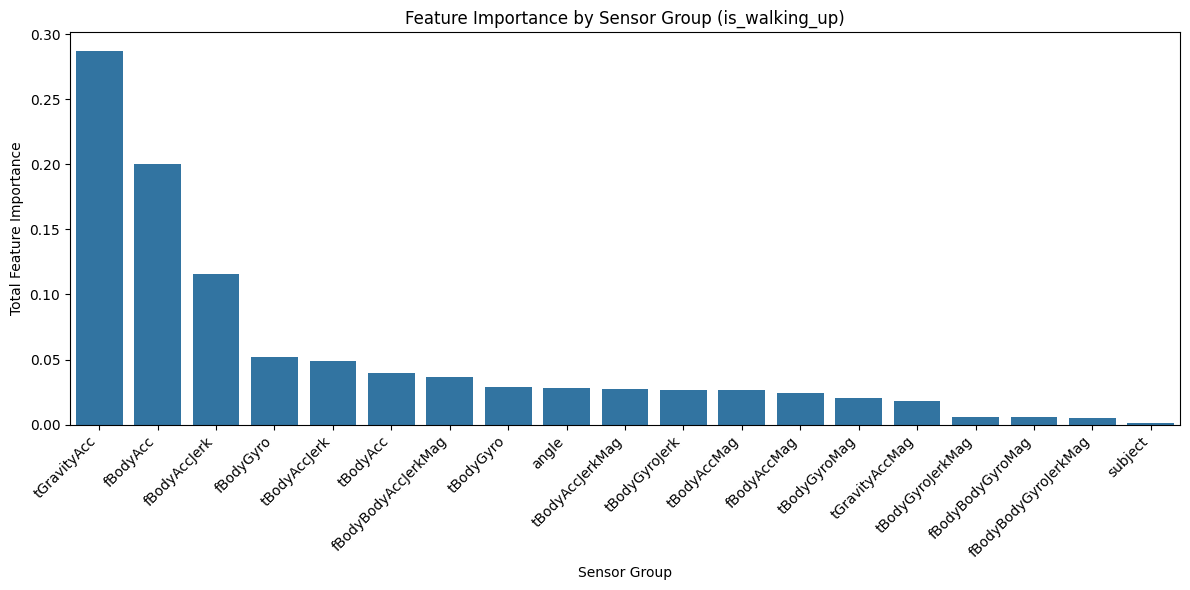

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_walk_up = r_walk_up.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_walk_up = sensor_importance_walk_up.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_walking_up):")
display(sensor_importance_walk_up)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_walk_up)
plt.title('Feature Importance by Sensor Group (is_walking_up)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_walking_up, 상위 10개):


,sensor,agg,feature_importance
394,tGravityAcc,min(),0.042271
54,fBodyAcc,max(),0.028933
381,tGravityAcc,"arCoeff()-Z,1",0.027180
61,fBodyAcc,std(),0.026200
388,tGravityAcc,energy(),0.023777
393,tGravityAcc,mean(),0.023037
382,tGravityAcc,"arCoeff()-Z,2",0.022801
377,tGravityAcc,"arCoeff()-Y,1",0.021827
217,fBodyGyro,maxInds,0.021781
110,fBodyAccJerk,maxInds,0.021596


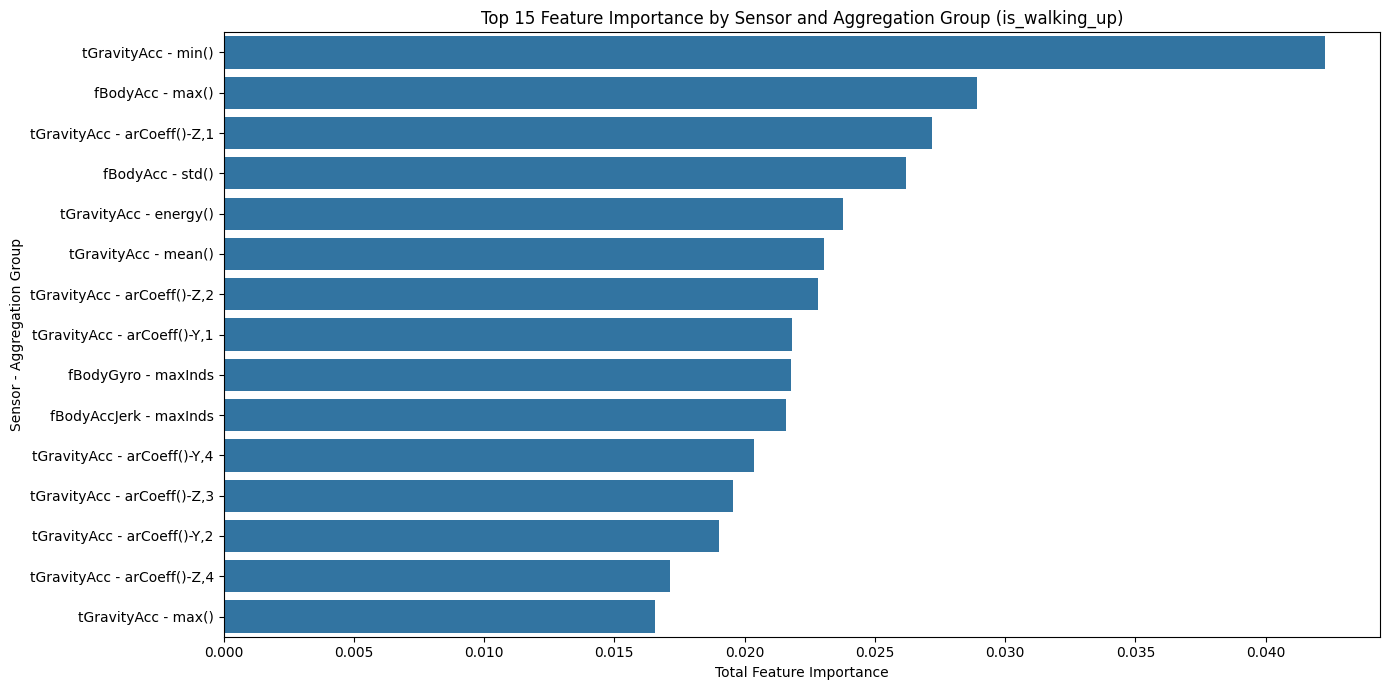

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_walk_up = r_walk_up.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_walk_up = sensor_agg_importance_walk_up.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_walking_up, 상위 10개):")
display(sensor_agg_importance_walk_up.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_walk_up['sensor_agg_group'] = sensor_agg_importance_walk_up['sensor'] + ' - ' + sensor_agg_importance_walk_up['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_walk_up.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_walking_up)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

### (7) 개별 동작 분석 : is_walking_down


* **세부 요구사항**
    - Target인 Activity를 is_walking_down 변수로 변경하시오.
        * 값 1 : WALKING_DOWNSTAIRS
        * 값 0 : 나머지
    - is_walking_down 을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_walking_down 을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_walking_down 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_walking_down 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


In [ ]:
# 'is_walking_down' 컬럼 추가
data['is_walking_down'] = (data['Activity'] == 'WALKING_DOWNSTAIRS').astype(int)

print("is_walking_down 값 분포:")
display(data['is_walking_down'].value_counts())
display(data.head())

is_walking_down 값 분포:


,count
is_walking_down,
0,5090
1,791


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(Z,gravityMean)",subject,Activity,is_dynamic,is_standing,is_sitting,is_laying,is_walking,is_walking_up,is_walking_down
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,0.165163,21,STANDING,0,1,0,0,0,0,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.147944,15,LAYING,0,0,0,1,0,0,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.032755,11,STANDING,0,1,0,0,0,0,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,0.111388,17,WALKING,1,0,0,0,1,0,0
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,0.137758,17,WALKING_DOWNSTAIRS,1,0,0,0,0,0,1


In [ ]:
#### is_walking_down 기본 모델 생성

# 데이터 분할을 위한 전처리
target_walking_down = 'is_walking_down'
x_walk_down = data.drop(['Activity', target_walking_down, 'is_dynamic', 'is_standing', 'is_sitting', 'is_laying', 'is_walking', 'is_walking_up'], axis=1)
y_walk_down = data.loc[:, target_walking_down]

x_train_walk_down, x_val_walk_down, y_train_walk_down, y_val_walk_down = train_test_split(x_walk_down, y_walk_down, test_size=0.3, random_state=42)

# 모델 생성 및 학습
model_walk_down = RandomForestClassifier(random_state=42)
model_walk_down.fit(x_train_walk_down, y_train_walk_down)
pred_walk_down = model_walk_down.predict(x_val_walk_down)

# 평가
print('accuracy (is_walking_down) :', accuracy_score(y_val_walk_down, pred_walk_down))
print('='*60)
print(confusion_matrix(y_val_walk_down, pred_walk_down))
print('='*60)
print(classification_report(y_val_walk_down, pred_walk_down))

accuracy (is_walking_down) : 0.9801699716713881
[[1517    9]
 [  26  213]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1526
           1       0.96      0.89      0.92       239

    accuracy                           0.98      1765
   macro avg       0.97      0.94      0.96      1765
weighted avg       0.98      0.98      0.98      1765



is_walking_down 예측에 중요한 상위 5개 변수: ['tBodyAccMag-std()', 'tGravityAccMag-std()', 'tBodyAccMag-mad()', 'tGravityAccMag-mad()', 'fBodyAccMag-mad()']


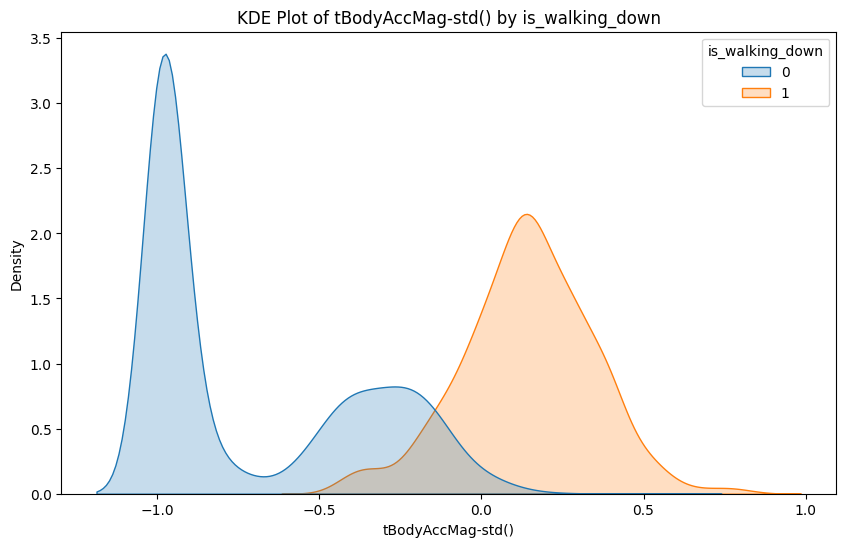

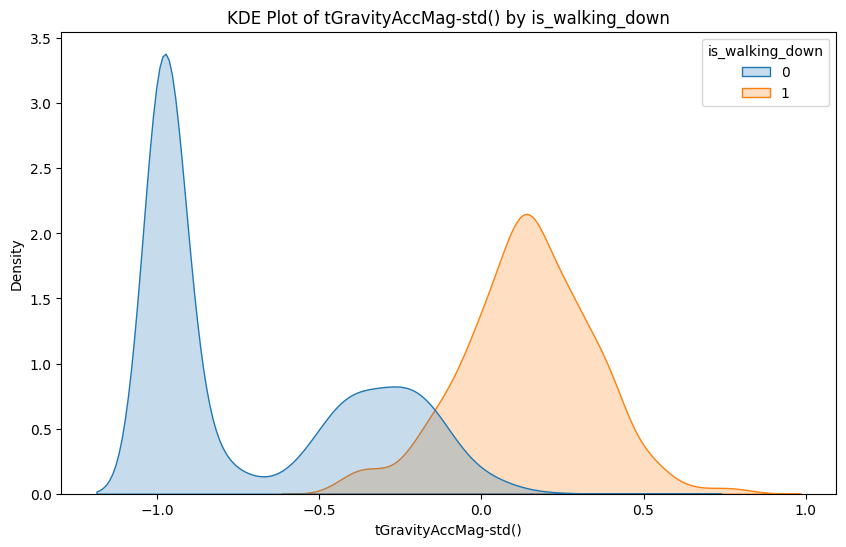

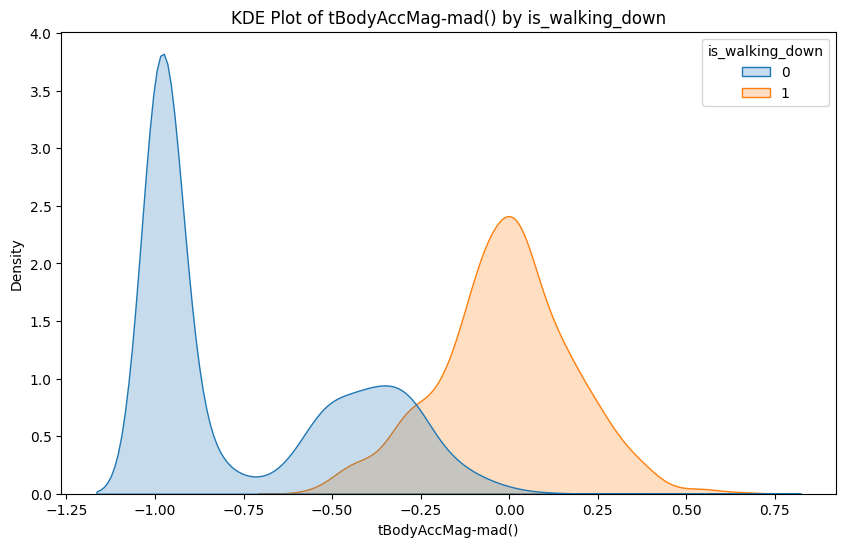

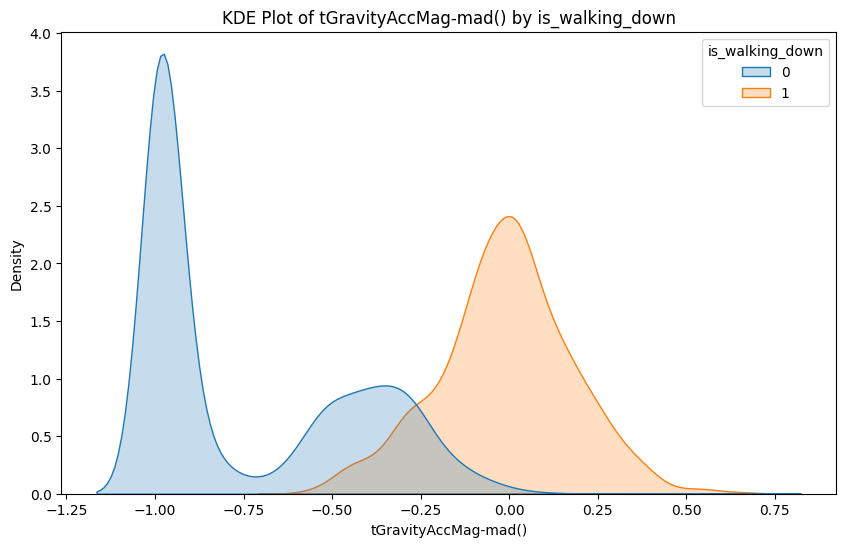

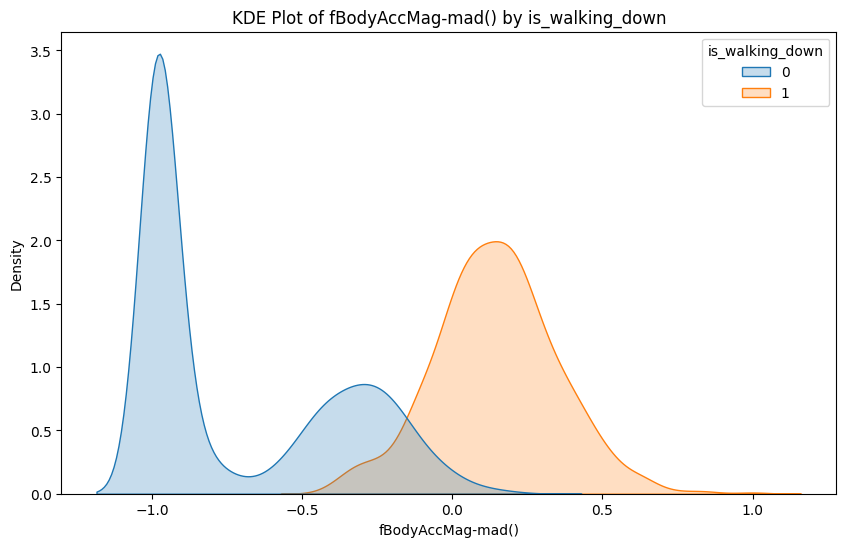

In [ ]:
#### is_walking_down 변수중요도 상위 5개 분석

# 변수 중요도 추출
r_walk_down = plot_feature_importance(model_walk_down.feature_importances_, list(x_train_walk_down.columns), result_only=True)

# 상위 5개 중요 변수 선정
top_5_walk_down_features = r_walk_down['feature_name'].head(5).tolist()
print(f"is_walking_down 예측에 중요한 상위 5개 변수: {top_5_walk_down_features}")

# 상위 5개 변수 각각에 대해 KDE plot 그리기
for feature in top_5_walk_down_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data, x=feature, hue='is_walking_down', fill=True, common_norm=False)
    plt.title(f'KDE Plot of {feature} by is_walking_down')
    plt.show()

In [ ]:
#### is_walking_down feature 그룹별 분석

# r_walk_down에 새로운 컬럼 생성 (features 데이터프레임과 병합하는 대신 parse_feature_name_to_components 함수 사용)
r_walk_down[['sensor', 'agg', 'axis']] = r_walk_down['feature_name'].apply(lambda x: pd.Series(parse_feature_name_to_components(x)))

print("Feature importance dataframe with parsed components (head) for is_walking_down:")
display(r_walk_down.head())

Feature importance dataframe with parsed components (head) for is_walking_down:


,feature_name,feature_importance,sensor,agg,axis
0,tBodyAccMag-std(),0.097003,tBodyAccMag,std(),None
1,tGravityAccMag-std(),0.056764,tGravityAccMag,std(),None
2,tBodyAccMag-mad(),0.045064,tBodyAccMag,mad(),None
3,tGravityAccMag-mad(),0.038856,tGravityAccMag,mad(),None
4,fBodyAccMag-mad(),0.038003,fBodyAccMag,mad(),None



Sensor 별 중요도 합계 (is_walking_down):


,sensor,feature_importance
12,tBodyAccMag,0.169290
3,fBodyAccMag,0.164993
1,fBodyAcc,0.155322
9,tBodyAcc,0.125328
18,tGravityAccMag,0.119271
2,fBodyAccJerk,0.061413
10,tBodyAccJerk,0.054925
17,tGravityAcc,0.042904
7,fBodyGyro,0.038662
13,tBodyGyro,0.018158


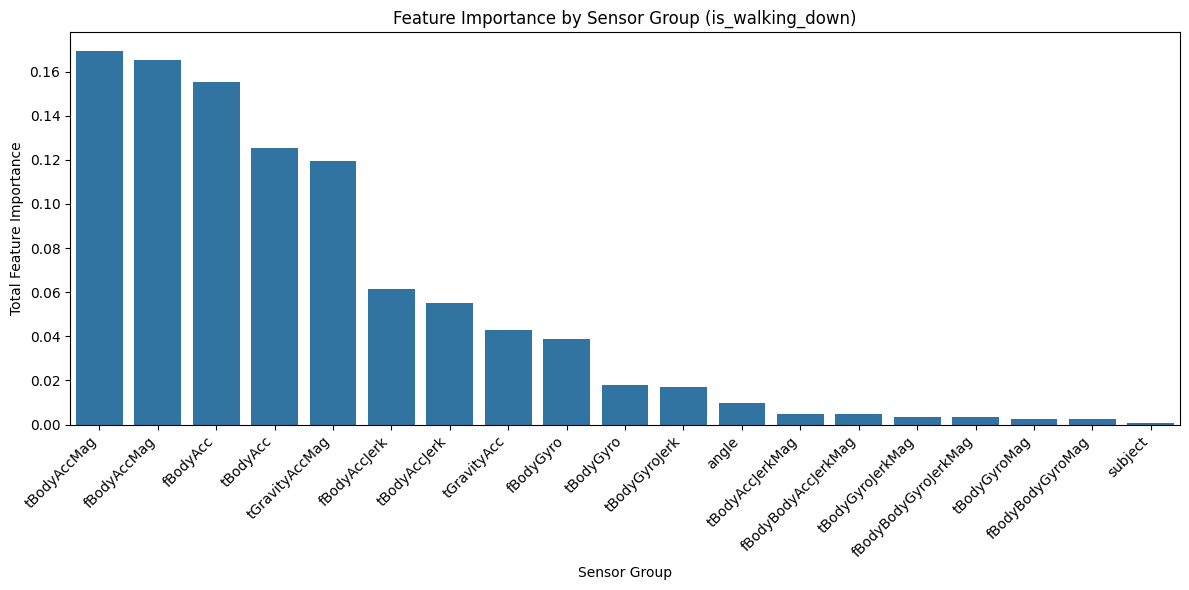

In [ ]:
# sensor 별 중요도 합계 계산
sensor_importance_walk_down = r_walk_down.groupby('sensor')['feature_importance'].sum().reset_index()
sensor_importance_walk_down = sensor_importance_walk_down.sort_values(by='feature_importance', ascending=False)

print("\nSensor 별 중요도 합계 (is_walking_down):")
display(sensor_importance_walk_down)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='sensor', y='feature_importance', data=sensor_importance_walk_down)
plt.title('Feature Importance by Sensor Group (is_walking_down)')
plt.xlabel('Sensor Group')
plt.ylabel('Total Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Sensor + Aggregation 별 중요도 합계 (is_walking_down, 상위 10개):


,sensor,agg,feature_importance
298,tBodyAccMag,std(),0.097003
409,tGravityAccMag,std(),0.056764
293,tBodyAccMag,mad(),0.045064
404,tGravityAccMag,mad(),0.038856
121,fBodyAccMag,mad(),0.038003
240,tBodyAcc,energy(),0.035344
117,fBodyAccMag,energy(),0.032938
128,fBodyAccMag,sma(),0.032231
53,fBodyAcc,mad(),0.031626
268,tBodyAccJerk,max(),0.030191


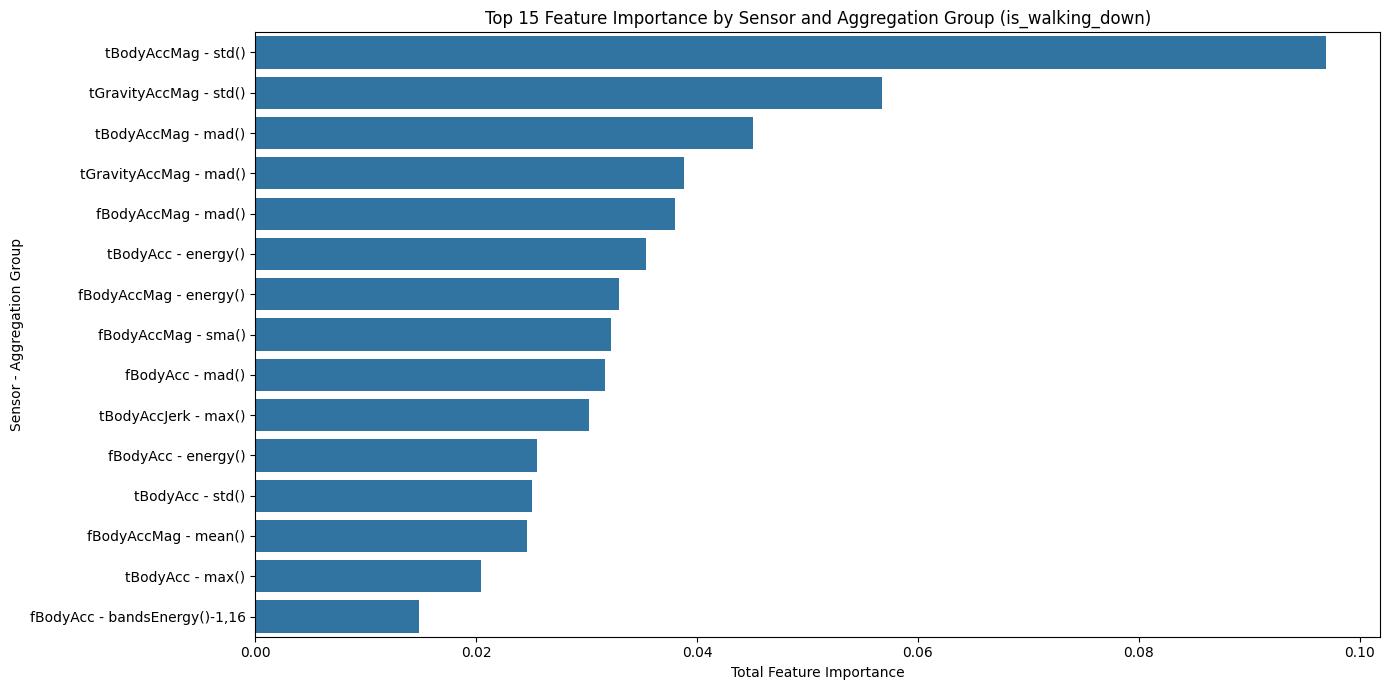

In [ ]:
# sensor + agg 별 중요도 합계 계산
sensor_agg_importance_walk_down = r_walk_down.groupby(['sensor', 'agg'])['feature_importance'].sum().reset_index()
sensor_agg_importance_walk_down = sensor_agg_importance_walk_down.sort_values(by='feature_importance', ascending=False)

print("\nSensor + Aggregation 별 중요도 합계 (is_walking_down, 상위 10개):")
display(sensor_agg_importance_walk_down.head(10))

# 시각화를 위해 'sensor_agg_group' 컬럼 생성
sensor_agg_importance_walk_down['sensor_agg_group'] = sensor_agg_importance_walk_down['sensor'] + ' - ' + sensor_agg_importance_walk_down['agg']

plt.figure(figsize=(14, 7))
sns.barplot(x='feature_importance', y='sensor_agg_group', data=sensor_agg_importance_walk_down.head(15))
plt.title('Top 15 Feature Importance by Sensor and Aggregation Group (is_walking_down)')
plt.xlabel('Total Feature Importance')
plt.ylabel('Sensor - Aggregation Group')
plt.tight_layout()
plt.show()

## 5.특성 중요도 저장하기

* **세부 요구사항**
    - 지금까지 변수 중요도를 다양한 관점에서 뽑고 분석을 해 보았습니다.
        - 관점1 : 6개 행동 구분
        - 관점2 : 동적, 정적 행동 구분
        - 관점3 : Standing 여부 구분
        - 관점4 : Sitting 여부 구분
        - 관점5 : Laying 여부 구분
        - 관점6 : Walking 여부 구분
        - 관점7 : Walking_upstairs 여부 구분
        - 관점8 : Walking_downstairs 여부 구분
    - 모든 관점의 변수 중요도를 하나로 합친 후 저장
        - merge를 이용하여 features와 합칩니다.
        - joblib 패키지의 dump를 이용하여 결과를 저장합니다.

### (1) 하나로 합치기
* 합치기 위해서는 중요도 결과에서 feature_importance 칼럼 이름을 수정해야 합니다.
* pd.merge를 이용해서 하나씩 합치는 작업을 반복 합니다.

In [ ]:
# 중요도 결과 칼럼 이름 수정
r0.rename(columns={'feature_importance': 'fi_all'}, inplace=True)
r_dyn.rename(columns={'feature_importance': 'fi_dynamic'}, inplace=True)
r_stand.rename(columns={'feature_importance': 'fi_standing'}, inplace=True)
r_sit.rename(columns={'feature_importance': 'fi_sitting'}, inplace=True)
r_lay.rename(columns={'feature_importance': 'fi_laying'}, inplace=True)
r_walk.rename(columns={'feature_importance': 'fi_walking'}, inplace=True)
r_walk_up.rename(columns={'feature_importance': 'fi_walking_up'}, inplace=True)
r_walk_down.rename(columns={'feature_importance': 'fi_walking_down'}, inplace=True)

# features 데이터와 r0 병합
fi_analysis = pd.merge(features, r0[['feature_name', 'fi_all']], on='feature_name', how='left')

# 나머지 중요도 결과 병합
fi_analysis = pd.merge(fi_analysis, r_dyn[['feature_name', 'fi_dynamic']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_stand[['feature_name', 'fi_standing']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_sit[['feature_name', 'fi_sitting']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_lay[['feature_name', 'fi_laying']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_walk[['feature_name', 'fi_walking']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_walk_up[['feature_name', 'fi_walking_up']], on='feature_name', how='left')
fi_analysis = pd.merge(fi_analysis, r_walk_down[['feature_name', 'fi_walking_down']], on='feature_name', how='left')

print("최종 변수 중요도 분석 데이터프레임 (fi_analysis) head:")
display(fi_analysis)

# 각 자세 혹은 행동 별로 어떤 센서,특징이 중요하게 기여 했나를 보여주는 것!

최종 변수 중요도 분석 데이터프레임 (fi_analysis) head:


,sensor,agg,axis,feature_name,fi_all,fi_dynamic,fi_standing,fi_sitting,fi_laying,fi_walking,fi_walking_up,fi_walking_down
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X,0.000279,0.000041,0.000218,0.000659,0.000444,0.000301,0.000092,0.000297
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y,0.000390,0.000000,0.000138,0.000872,0.000405,0.000232,0.000582,0.000237
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z,0.000180,0.000049,0.000212,0.000280,0.000031,0.000033,0.000197,0.000408
3,tBodyAcc,std(),X,tBodyAcc-std()-X,0.005243,0.000010,0.004866,0.001226,0.000138,0.003572,0.003501,0.023573
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y,0.000246,0.000000,0.001068,0.000426,0.000131,0.000119,0.000255,0.000947
...,...,...,...,...,...,...,...,...,...,...,...,...
556,angle,tBodyGyroMean,gravityMean,"angle(tBodyGyroMean,gravityMean)",0.000522,0.000000,0.000547,0.000681,0.000169,0.000038,0.000895,0.000125
557,angle,tBodyGyroJerkMean,gravityMean,"angle(tBodyGyroJerkMean,gravityMean)",0.000332,0.000000,0.002287,0.001234,0.000000,0.000210,0.000112,0.000322
558,angle,X,gravityMean,"angle(X,gravityMean)",0.032505,0.000137,0.018559,0.033269,0.063431,0.002431,0.008163,0.001612
559,angle,Y,gravityMean,"angle(Y,gravityMean)",0.024427,0.000049,0.062431,0.035773,0.053630,0.003303,0.016054,0.006360


In [ ]:
#fi_analysis 데이터 불러오기
#data_path = "./fi_analysis.csv"
#fi_analysis = pd.read_csv(data_path)
#r_dyn = fi_analysis.filter(items=['feature_name','fi_all'])
#r_dyn.rename(columns={'fi_dynamic':'feature_importance'}, inplace=True)
#r_dyn.sort_values(by=['feature_importance'], axis=0, ascending=False)

In [ ]:
#fi_analysis 데이터 불러오기
#data_path = "./fi_analysis.csv"
#fi_analysis = pd.read_csv(data_path)
#r_dyn = fi_analysis.filter(items=['feature_name','fi_all'])
#r_dyn.rename(columns={'fi_dynamic':'feature_importance'}, inplace=True)
#r_dyn.sort_values(by=['feature_importance'], axis=0, ascending=False)

### (2) 저장하기
* joblib.dump를 이용하시오.
* 저장할 파일의 확장자는 보통 .pkl 입니다.

In [ ]:
# # joblib.dump를 이용하여 결과 저장
# output_path = '/content/drive/MyDrive/fi_analysis.pkl' # 원하는 저장 경로로 변경해주세요.
# joblib.dump(fi_analysis, output_path)

# print(f"변수 중요도 분석 결과가 '{output_path}' 에 저장되었습니다.")